In [1]:
!pip install -q pretty_midi music21 numpy matplotlib tqdm pandas
!pip install -q torch torchvision torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 51.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
!wget -O maestro-v3.0.0-midi.zip https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
!unzip -q maestro-v3.0.0-midi.zip

--2026-04-24 13:35:15--  https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.98.207, 142.251.107.207, 74.125.196.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58416533 (56M) [application/octet-stream]
Saving to: ‘maestro-v3.0.0-midi.zip’

maestro-v3.0.0-midi 100%[===================>]  55.71M   119MB/s    in 0.5s    

2026-04-24 13:35:15 (119 MB/s) - ‘maestro-v3.0.0-midi.zip’ saved [58416533/58416533]



In [5]:
DATASET_PATH = "/content/maestro-v3.0.0"

midi_files = glob.glob(os.path.join(DATASET_PATH, "**/*.midi"), recursive=True)
midi_files = sorted(midi_files)

print("Total MIDI files found:", len(midi_files))
print("First 5 files:")
for f in midi_files[:5]:
    print(f)

Total MIDI files found: 1276
First 5 files:
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_06_Track06_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_10_Track10_wav.midi
/content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_05_R1_2004_01_ORIG_MID--AUDIO_05_R1_2004_02_Track02_wav.midi


In [6]:
SEQ_LEN = 64
STRIDE = 32
FS = 8
MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 3000
MIN_ACTIVE_NOTES = 12

BATCH_SIZE = 32
HIDDEN_DIM = 256
LATENT_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 35
PATIENCE = 7

GENRE_EMBED_DIM = 16
BETA_MAX = 0.1

OUTPUT_DIR = "/content/outputs_task1_fixed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("PITCH_DIM =", PITCH_DIM)

PITCH_DIM = 88


In [7]:
def midi_to_pianoroll(midi_path, fs=FS, min_pitch=MIN_PITCH, max_pitch=MAX_PITCH):
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        piano_roll = midi_data.get_piano_roll(fs=fs)  # (128, time)

        # keep only piano range
        piano_roll = piano_roll[min_pitch:max_pitch + 1, :]

        # binarize note activations
        piano_roll = (piano_roll > 0).astype(np.float32)

        # transpose to (time, pitch)
        piano_roll = piano_roll.T
        return piano_roll

    except Exception as e:
        print(f"Error processing {midi_path}: {e}")
        return None

In [8]:
def create_sequences(piano_roll, seq_len=SEQ_LEN, stride=STRIDE, min_active_notes=MIN_ACTIVE_NOTES):
    sequences = []
    total_steps = len(piano_roll)

    if total_steps < seq_len:
        return sequences

    for i in range(0, total_steps - seq_len + 1, stride):
        seq = piano_roll[i:i + seq_len]

        if np.sum(seq) < min_active_notes:
            continue

        sequences.append(seq.astype(np.float32))

    return sequences

In [9]:
all_sequences = []
used_files = 0
MAX_SEQUENCES = 3000  # limit total number of sequences

for midi_path in tqdm(midi_files, desc="Processing MIDI files"):
    piano_roll = midi_to_pianoroll(midi_path)

    if piano_roll is None:
        continue

    seqs = create_sequences(piano_roll)

    if len(seqs) > 0:
        used_files += 1

    for seq in seqs:
        all_sequences.append(seq)

        if len(all_sequences) >= MAX_SEQUENCES:
            break

    if len(all_sequences) >= MAX_SEQUENCES:
        break

all_sequences = np.array(all_sequences, dtype=np.float32)

print("Total usable sequences:", len(all_sequences))
print("Files used:", used_files)
print("Dataset shape:", all_sequences.shape)

Processing MIDI files:   1%|▏         | 18/1276 [00:10<12:12,  1.72it/s]

Total usable sequences: 3000
Files used: 19
Dataset shape: (3000, 64, 88)


In [10]:
indices = np.arange(len(all_sequences))
np.random.shuffle(indices)

all_sequences = all_sequences[indices]

train_size = int(0.8 * len(all_sequences))
val_size = int(0.1 * len(all_sequences))

train_data = all_sequences[:train_size]
val_data = all_sequences[train_size:train_size + val_size]
test_data = all_sequences[train_size + val_size:]

print("Train:", train_data.shape)
print("Val:", val_data.shape)
print("Test:", test_data.shape)

Train: (2400, 64, 88)
Val: (300, 64, 88)
Test: (300, 64, 88)


In [11]:
class MusicDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x  # autoencoder target = input


train_dataset = MusicDataset(train_data)
val_dataset = MusicDataset(val_data)
test_dataset = MusicDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 75
Val batches: 10
Test batches: 10


In [12]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=PITCH_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.fc_latent = nn.Linear(hidden_dim, latent_dim)

        self.fc_h = nn.Linear(latent_dim, hidden_dim * num_layers)
        self.fc_c = nn.Linear(latent_dim, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        z = self.fc_latent(h_last)
        return z

    def decode(self, z, seq_len):
        batch_size = z.size(0)

        h0 = self.fc_h(z).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_c(z).view(self.num_layers, batch_size, self.hidden_dim)

        decoder_input = torch.zeros(batch_size, seq_len, self.input_dim, device=z.device)
        decoded_seq, _ = self.decoder_lstm(decoder_input, (h0, c0))

        logits = self.output_layer(decoded_seq)
        return logits

    def forward(self, x):
        z = self.encode(x)
        logits = self.decode(z, x.size(1))
        return logits

In [13]:
model = LSTMAutoencoder().to(device)

pos_weight = torch.full((PITCH_DIM,), 4.0).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

LSTMAutoencoder(
  (encoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc_latent): Linear(in_features=256, out_features=128, bias=True)
  (fc_h): Linear(in_features=128, out_features=512, bias=True)
  (fc_c): Linear(in_features=128, out_features=512, bias=True)
  (decoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=256, out_features=88, bias=True)
)


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        recon = model(x)
        loss = criterion(recon, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            recon = model(x)
            loss = criterion(recon, y)
            total_loss += loss.item()

    return total_loss / len(loader)

In [15]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model_path = os.path.join(OUTPUT_DIR, "best_lstm_autoencoder.pt")
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation loss:", best_val_loss)
print("Saved best model to:", best_model_path)

Epoch [1/35] | Train Loss: 0.5119 | Val Loss: 0.4458
Epoch [2/35] | Train Loss: 0.4742 | Val Loss: 0.4442
Epoch [3/35] | Train Loss: 0.4741 | Val Loss: 0.4441
Epoch [4/35] | Train Loss: 0.4737 | Val Loss: 0.4443
Epoch [5/35] | Train Loss: 0.4735 | Val Loss: 0.4460
Epoch [6/35] | Train Loss: 0.4737 | Val Loss: 0.4462
Epoch [7/35] | Train Loss: 0.4738 | Val Loss: 0.4434
Epoch [8/35] | Train Loss: 0.4732 | Val Loss: 0.4460
Epoch [9/35] | Train Loss: 0.4733 | Val Loss: 0.4434
Epoch [10/35] | Train Loss: 0.4734 | Val Loss: 0.4444
Epoch [11/35] | Train Loss: 0.4733 | Val Loss: 0.4445
Epoch [12/35] | Train Loss: 0.4732 | Val Loss: 0.4427
Epoch [13/35] | Train Loss: 0.4732 | Val Loss: 0.4429
Epoch [14/35] | Train Loss: 0.4734 | Val Loss: 0.4435
Epoch [15/35] | Train Loss: 0.4732 | Val Loss: 0.4467
Epoch [16/35] | Train Loss: 0.4732 | Val Loss: 0.4429
Epoch [17/35] | Train Loss: 0.4731 | Val Loss: 0.4447
Epoch [18/35] | Train Loss: 0.4732 | Val Loss: 0.4437
Epoch [19/35] | Train Loss: 0.4728 | 

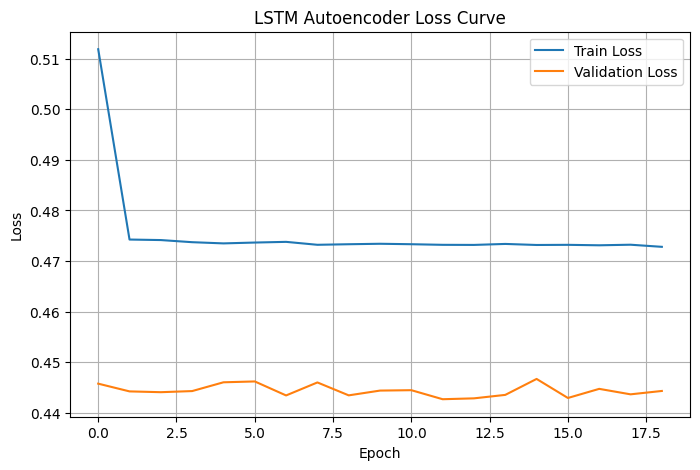

Saved loss plot to: /content/outputs_task1_fixed/loss_curve_task1.png


In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder Loss Curve")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(OUTPUT_DIR, "loss_curve_task1.png")
plt.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved loss plot to:", loss_plot_path)

In [17]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Best model loaded.")

Best model loaded.


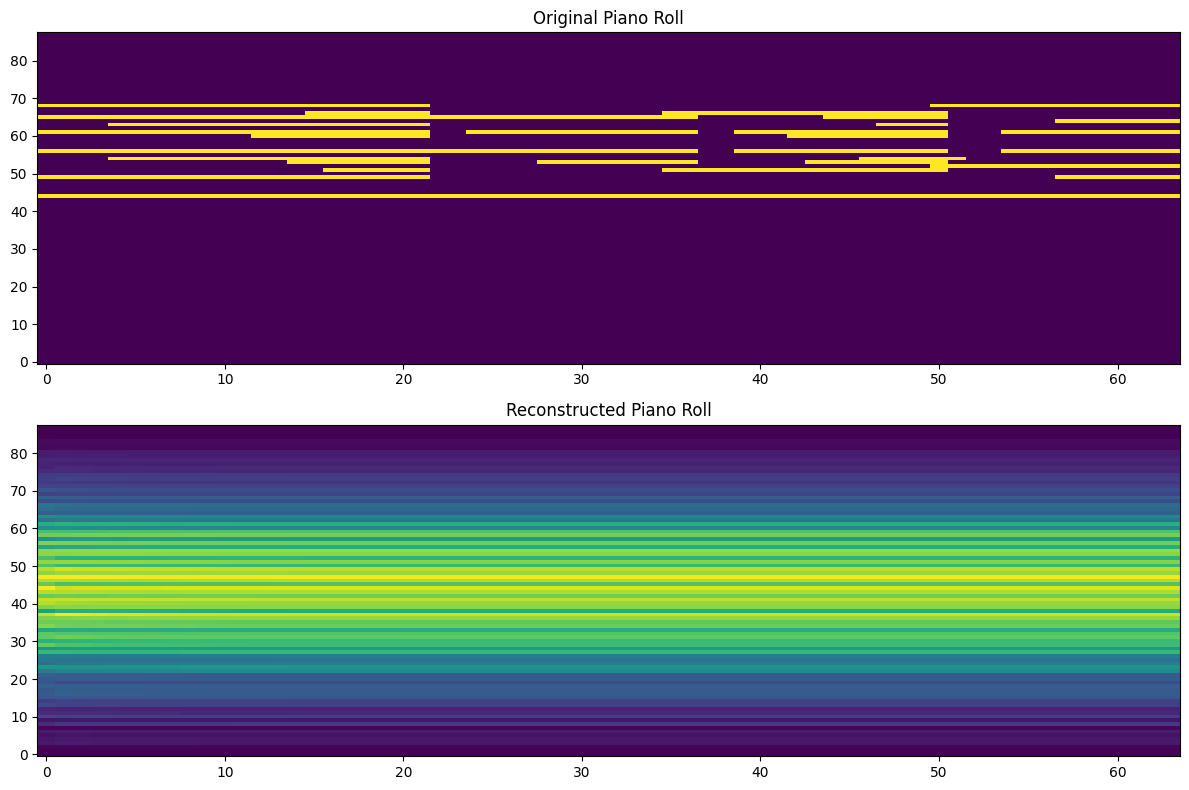

In [18]:
x_batch, _ = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    recon_batch = torch.sigmoid(model(x_batch))

original = x_batch[0].cpu().numpy()
reconstructed = recon_batch[0].cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].imshow(original.T, aspect='auto', origin='lower')
axes[0].set_title("Original Piano Roll")

axes[1].imshow(reconstructed.T, aspect='auto', origin='lower')
axes[1].set_title("Reconstructed Piano Roll")

plt.tight_layout()
plt.show()

In [19]:
def binarize_pianoroll(piano_roll, threshold=0.5, max_polyphony=6, min_keep_prob=0.35):
    pr = np.array(piano_roll, copy=True)
    binary_roll = np.zeros_like(pr, dtype=np.int32)

    for t in range(pr.shape[0]):
        row = pr[t]

        active = np.where(row >= threshold)[0]

        if len(active) == 0:
            best_idx = np.argmax(row)
            if row[best_idx] >= min_keep_prob:
                active = np.array([best_idx])

        if len(active) > max_polyphony:
            active = active[np.argsort(row[active])[-max_polyphony:]]

        binary_roll[t, active] = 1

    return binary_roll


def pianoroll_to_midi(piano_roll, output_path, fs=FS, min_pitch=MIN_PITCH,
                      threshold=0.5, max_polyphony=6, min_keep_prob=0.35):

    binary_roll = binarize_pianoroll(
        piano_roll,
        threshold=threshold,
        max_polyphony=max_polyphony,
        min_keep_prob=min_keep_prob
    )

    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)
    time_per_step = 1.0 / fs

    for pitch_idx in range(binary_roll.shape[1]):
        pitch = pitch_idx + min_pitch
        note_on = None

        for t in range(binary_roll.shape[0]):
            value = binary_roll[t, pitch_idx]

            if value == 1 and note_on is None:
                note_on = t * time_per_step

            elif value == 0 and note_on is not None:
                note_off = t * time_per_step
                if note_off > note_on:
                    instrument.notes.append(
                        pretty_midi.Note(
                            velocity=100,
                            pitch=pitch,
                            start=note_on,
                            end=note_off
                        )
                    )
                note_on = None

        if note_on is not None:
            note_off = binary_roll.shape[0] * time_per_step
            if note_off > note_on:
                instrument.notes.append(
                    pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=note_on,
                        end=note_off
                    )
                )

    pm.instruments.append(instrument)
    pm.write(output_path)

    return binary_roll

In [20]:
recon_dir = os.path.join(OUTPUT_DIR, "generated_midis_task1_reconstructed")
os.makedirs(recon_dir, exist_ok=True)

saved = 0
for i in range(len(test_data)):
    x = torch.tensor(test_data[i], dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        recon = torch.sigmoid(model(x)).squeeze(0).cpu().numpy()

    out_path = os.path.join(recon_dir, f"reconstructed_{saved+1}.mid")
    pianoroll_to_midi(recon, out_path, threshold=0.5, max_polyphony=6)

    saved += 1
    if saved == 5:
        break

print("Saved 5 reconstructed MIDI files to:", recon_dir)

Saved 5 reconstructed MIDI files to: /content/outputs_task1_fixed/generated_midis_task1_reconstructed


In [21]:
def generate_from_latent(model, source_loader, num_samples=5, seq_len=SEQ_LEN, noise_std=0.15):
    model.eval()

    latent_bank = []

    with torch.no_grad():
        for x, _ in source_loader:
            x = x.to(device)
            z = model.encode(x)
            latent_bank.append(z.cpu())

            if sum(chunk.size(0) for chunk in latent_bank) >= 256:
                break

    latent_bank = torch.cat(latent_bank, dim=0)

    idx = torch.randint(0, latent_bank.size(0), (num_samples,))
    z = latent_bank[idx].to(device)
    z = z + noise_std * torch.randn_like(z)

    with torch.no_grad():
        samples = torch.sigmoid(model.decode(z, seq_len)).cpu().numpy()

    return samples

In [22]:
sampled_dir = os.path.join(OUTPUT_DIR, "generated_midis_task1_sampled")
os.makedirs(sampled_dir, exist_ok=True)

generated_samples = generate_from_latent(model, train_loader, num_samples=5)

for i, sample in enumerate(generated_samples):
    out_path = os.path.join(sampled_dir, f"generated_{i+1}.mid")
    pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)

print("Saved 5 generated MIDI files to:", sampled_dir)

Saved 5 generated MIDI files to: /content/outputs_task1_fixed/generated_midis_task1_sampled


In [23]:
test_loss = validate_one_epoch(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.4934


In [24]:
def compute_pitch_class_histogram(piano_roll, min_pitch=MIN_PITCH):
    piano_roll = (piano_roll > 0).astype(np.int32)
    pitch_activity = np.sum(piano_roll, axis=0).astype(np.float64)

    hist = np.zeros(12, dtype=np.float64)
    for i, value in enumerate(pitch_activity):
        midi_pitch = min_pitch + i
        pitch_class = midi_pitch % 12
        hist[pitch_class] += value

    total = np.sum(hist)
    if total > 0:
        hist /= total

    return hist


def histogram_distance(h1, h2):
    return np.sum(np.abs(h1 - h2))


real_seq = test_data[0]
gen_seq = generated_samples[0]

gen_binary = binarize_pianoroll(gen_seq, threshold=0.5, max_polyphony=6)

real_hist = compute_pitch_class_histogram(real_seq)
gen_hist = compute_pitch_class_histogram(gen_binary)

pitch_hist_distance = histogram_distance(real_hist, gen_hist)
print("Pitch Histogram Distance:", round(float(pitch_hist_distance), 4))

Pitch Histogram Distance: 2.0


In [25]:
def rhythm_diversity_score(piano_roll):
    piano_roll = (piano_roll > 0).astype(np.int32)
    durations = []

    for pitch_idx in range(piano_roll.shape[1]):
        current_duration = 0
        for t in range(piano_roll.shape[0]):
            if piano_roll[t, pitch_idx] == 1:
                current_duration += 1
            elif current_duration > 0:
                durations.append(current_duration)
                current_duration = 0

        if current_duration > 0:
            durations.append(current_duration)

    if len(durations) == 0:
        return 0.0

    return len(set(durations)) / len(durations)

real_rhythm_div = rhythm_diversity_score(real_seq)
gen_rhythm_div = rhythm_diversity_score(gen_binary)

print("Real Rhythm Diversity:", round(real_rhythm_div, 4))
print("Generated Rhythm Diversity:", round(gen_rhythm_div, 4))

Real Rhythm Diversity: 0.4828
Generated Rhythm Diversity: 1.0


In [26]:
def repetition_ratio(piano_roll, pattern_len=4):
    piano_roll = (piano_roll > 0).astype(np.int32)
    patterns = []

    for i in range(0, len(piano_roll) - pattern_len + 1):
        pattern = tuple(piano_roll[i:i+pattern_len].flatten().tolist())
        patterns.append(pattern)

    if len(patterns) == 0:
        return 0.0

    unique_patterns = len(set(patterns))
    repeated_patterns = len(patterns) - unique_patterns

    return repeated_patterns / len(patterns)

real_rep = repetition_ratio(real_seq)
gen_rep = repetition_ratio(gen_binary)

print("Real Repetition Ratio:", round(real_rep, 4))
print("Generated Repetition Ratio:", round(gen_rep, 4))

Real Repetition Ratio: 0.1967
Generated Repetition Ratio: 0.9836


In [27]:
results = pd.DataFrame([
    {
        "Model": "LSTM Autoencoder",
        "Test Loss": float(test_loss),
        "Pitch Histogram Distance": float(pitch_hist_distance),
        "Generated Rhythm Diversity": float(gen_rhythm_div),
        "Generated Repetition Ratio": float(gen_rep)
    }
])

metrics_csv_path = os.path.join(OUTPUT_DIR, "task1_metrics.csv")
results.to_csv(metrics_csv_path, index=False)

print(results)
print("Saved metrics to:", metrics_csv_path)

              Model  Test Loss  Pitch Histogram Distance  \
0  LSTM Autoencoder   0.493355                       2.0   

   Generated Rhythm Diversity  Generated Repetition Ratio  
0                         1.0                    0.983607  
Saved metrics to: /content/outputs_task1_fixed/task1_metrics.csv


In [28]:
!zip -r /content/task1_outputs_fixed.zip /content/outputs_task1_fixed > /dev/null
print("Created: /content/task1_outputs_fixed.zip")

Created: /content/task1_outputs_fixed.zip


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Task2**

In [30]:
GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

In [31]:
SEQ_LEN = 32
STRIDE = 16
FS = 8

MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 500
MIN_ACTIVE_NOTES = 4

In [32]:
import os
import glob

files = glob.glob(os.path.join("/content/maestro-v3.0.0", "**", "*.midi"), recursive=True)
files = sorted(files)

print("Number of MIDI files:", len(files))
print("First file:", files[0])

sample_file = files[0]
pr = midi_to_pianoroll(sample_file)

print("piano_roll is None?", pr is None)
if pr is not None:
    print("piano_roll shape:", pr.shape)
    print("sum of notes:", np.sum(pr))

Number of MIDI files: 1276
First file: /content/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.midi
piano_roll is None? False
piano_roll shape: (7752, 88)
sum of notes: 17803.0


In [33]:
seqs = create_sequences(pr, seq_len=SEQ_LEN, stride=STRIDE, min_active_notes=MIN_ACTIVE_NOTES)

print("Number of sequences from one file:", len(seqs))
if len(seqs) > 0:
    print("One sequence shape:", seqs[0].shape)
    print("Sequence sum:", np.sum(seqs[0]))

Number of sequences from one file: 483
One sequence shape: (32, 88)
Sequence sum: 70.0


In [34]:
all_sequences = []
all_labels = []
used_files = {g: 0 for g in GENRE_FOLDERS}

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "**", "*.mid"), recursive=True)
    files += glob.glob(os.path.join(folder, "**", "*.midi"), recursive=True)
    files = sorted(list(set(files)))

    print(f"\nProcessing genre: {genre}")
    print(f"Found files: {len(files)}")

    collected = 0

    for midi_path in files:
        piano_roll = midi_to_pianoroll(midi_path)

        if piano_roll is None:
            continue

        seqs = create_sequences(
            piano_roll,
            seq_len=SEQ_LEN,
            stride=STRIDE,
            min_active_notes=MIN_ACTIVE_NOTES
        )

        if len(seqs) > 0:
            used_files[genre] += 1

        for seq in seqs:
            all_sequences.append(seq)
            all_labels.append(genre_to_id[genre])
            collected += 1

            if collected >= MAX_SEQUENCES_PER_GENRE:
                break

        if collected >= MAX_SEQUENCES_PER_GENRE:
            break

    print(f"Collected sequences for {genre}: {collected}")

all_sequences = np.array(all_sequences, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

print("\n========== FINAL DATASET CHECK ==========")
print("Total sequences:", len(all_sequences))
print("all_sequences shape:", all_sequences.shape)
print("all_labels shape:", all_labels.shape)
print("Used files per genre:", used_files)


Processing genre: classical
Found files: 0
Collected sequences for classical: 0

Processing genre: jazz
Found files: 0
Collected sequences for jazz: 0

Processing genre: pop
Found files: 0
Collected sequences for pop: 0

Processing genre: rock
Found files: 0
Collected sequences for rock: 0

========== FINAL DATASET CHECK ==========
Total sequences: 0
all_sequences shape: (0,)
all_labels shape: (0,)
Used files per genre: {'classical': 0, 'jazz': 0, 'pop': 0, 'rock': 0}


In [35]:
print("piano_roll is None?", pr is None)
print("Number of sequences from one file:", len(seqs))
print("Total sequences:", len(all_sequences))

piano_roll is None? False
Number of sequences from one file: 483
Total sequences: 0


In [36]:
!mkdir -p /content/task2_data/classical
!mkdir -p /content/task2_data/jazz
!mkdir -p /content/task2_data/pop
!mkdir -p /content/task2_data/rock

In [37]:
!wget -O /content/groove-v1.0.0-midionly.zip \
https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip

--2026-04-24 13:36:28--  https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.212.207, 192.178.219.207, 173.194.215.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.212.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3260318 (3.1M) [application/zip]
Saving to: ‘/content/groove-v1.0.0-midionly.zip’

/content/groove-v1. 100%[===================>]   3.11M  --.-KB/s    in 0.01s   

2026-04-24 13:36:28 (259 MB/s) - ‘/content/groove-v1.0.0-midionly.zip’ saved [3260318/3260318]



In [38]:
!mkdir -p /content/groove_raw
!unzip -q /content/groove-v1.0.0-midionly.zip -d /content/groove_raw

In [39]:
!find /content/maestro-v3.0.0 -iname "*.midi" | head -300 | xargs -I {} cp "{}" /content/task2_data/classical/

In [40]:
import os
import glob
import shutil
import pandas as pd

# Find metadata
info_files = glob.glob("/content/groove_raw/**/info.csv", recursive=True)
print("info.csv files found:", info_files)

groove_info = info_files[0]
groove_root = os.path.dirname(groove_info)

df = pd.read_csv(groove_info)

# Main style label
df["primary_style"] = df["style"].str.split("/").str[0]

# Make sure destination folders exist
for style in ["jazz", "pop", "rock"]:
    os.makedirs(f"/content/task2_data/{style}", exist_ok=True)

for style in ["jazz", "pop", "rock"]:
    subset = df[df["primary_style"] == style].copy()
    print(style, "rows in metadata:", len(subset))

    copied = 0
    for _, row in subset.iterrows():
        src = os.path.join(groove_root, row["midi_filename"])

        # make safe flat filename
        safe_name = str(row["id"]).replace("/", "_").replace("\\", "_")
        dst = f"/content/task2_data/{style}/{safe_name}.mid"

        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied += 1

    print(style, "copied files:", copied)

info.csv files found: ['/content/groove_raw/groove/info.csv']
jazz rows in metadata: 101
jazz copied files: 101
pop rows in metadata: 27
pop copied files: 27
rock rows in metadata: 341
rock copied files: 341


In [41]:
import glob
import os

GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "*.mid"))
    files += glob.glob(os.path.join(folder, "*.midi"))
    print(genre, len(files))
    if files:
        print(" first file:", files[0])

classical 300
 first file: /content/task2_data/classical/MIDI-Unprocessed_12_R1_2006_01-08_ORIG_MID--AUDIO_12_R1_2006_06_Track06_wav.midi
jazz 101
 first file: /content/task2_data/jazz/drummer1_session1_57.mid
pop 27
 first file: /content/task2_data/pop/drummer7_eval_session_7.mid
rock 341
 first file: /content/task2_data/rock/drummer3_session2_20.mid


In [42]:
def midi_to_pianoroll(midi_path, fs=FS, min_pitch=MIN_PITCH, max_pitch=MAX_PITCH):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)

        if len(pm.instruments) == 0:
            return None

        end_time = pm.get_end_time()
        if end_time <= 0:
            return None

        n_steps = int(np.ceil(end_time * fs)) + 1
        piano_roll = np.zeros((n_steps, 128), dtype=np.float32)

        for inst in pm.instruments:
            for note in inst.notes:
                pitch = note.pitch

                if pitch < min_pitch or pitch > max_pitch:
                    continue

                start_step = int(np.floor(note.start * fs))
                end_step = int(np.ceil(note.end * fs))

                # very important for drum / short notes
                if end_step <= start_step:
                    end_step = start_step + 1

                piano_roll[start_step:end_step, pitch] = 1.0

        piano_roll = piano_roll[:, min_pitch:max_pitch + 1]

        if piano_roll.shape[0] == 0 or np.sum(piano_roll) == 0:
            return None

        return piano_roll

    except Exception as e:
        print("Error in", midi_path, ":", e)
        return None

In [43]:
SEQ_LEN = 32
STRIDE = 16
FS = 8

MIN_PITCH = 21
MAX_PITCH = 108
PITCH_DIM = MAX_PITCH - MIN_PITCH + 1

MAX_SEQUENCES_PER_GENRE = 500
MIN_ACTIVE_NOTES = 1

In [44]:
GENRE_FOLDERS = {
    "classical": "/content/task2_data/classical",
    "jazz": "/content/task2_data/jazz",
    "pop": "/content/task2_data/pop",
    "rock": "/content/task2_data/rock",
}

genre_to_id = {
    "classical": 0,
    "jazz": 1,
    "pop": 2,
    "rock": 3,
}

id_to_genre = {v: k for k, v in genre_to_id.items()}
NUM_GENRES = len(genre_to_id)

print(genre_to_id)
print("NUM_GENRES =", NUM_GENRES)

{'classical': 0, 'jazz': 1, 'pop': 2, 'rock': 3}
NUM_GENRES = 4


In [45]:
import glob
import numpy as np

jazz_files = glob.glob("/content/task2_data/jazz/*.mid") + glob.glob("/content/task2_data/jazz/*.midi")
jazz_files = sorted(jazz_files)

print("Jazz files:", len(jazz_files))
print("First jazz file:", jazz_files[0])

test_jazz = jazz_files[0]
pr_jazz = midi_to_pianoroll(test_jazz)

print("pr_jazz is None?", pr_jazz is None)
if pr_jazz is not None:
    print("pr_jazz shape:", pr_jazz.shape)
    print("sum of notes:", np.sum(pr_jazz))

Jazz files: 101
First jazz file: /content/task2_data/jazz/drummer10_session1_1.mid
pr_jazz is None? False
pr_jazz shape: (1316, 88)
sum of notes: 1905.0


In [46]:
seqs_jazz = create_sequences(
    pr_jazz,
    seq_len=SEQ_LEN,
    stride=STRIDE,
    min_active_notes=MIN_ACTIVE_NOTES
)

print("Number of jazz sequences from one file:", len(seqs_jazz))
if len(seqs_jazz) > 0:
    print("One sequence shape:", seqs_jazz[0].shape)
    print("Sequence sum:", np.sum(seqs_jazz[0]))

Number of jazz sequences from one file: 81
One sequence shape: (32, 88)
Sequence sum: 32.0


In [47]:
all_sequences = []
all_labels = []
used_files = {g: 0 for g in GENRE_FOLDERS}

MAX_SEQUENCES_PER_GENRE = 500

for genre, folder in GENRE_FOLDERS.items():
    files = glob.glob(os.path.join(folder, "*.mid"))
    files += glob.glob(os.path.join(folder, "*.midi"))
    files = sorted(list(set(files)))

    print(f"\nProcessing genre: {genre}")
    print(f"Found files: {len(files)}")

    collected = 0

    for midi_path in files:
        piano_roll = midi_to_pianoroll(midi_path)

        if piano_roll is None:
            continue

        seqs = create_sequences(
            piano_roll,
            seq_len=SEQ_LEN,
            stride=STRIDE,
            min_active_notes=MIN_ACTIVE_NOTES
        )

        if len(seqs) > 0:
            used_files[genre] += 1

        for seq in seqs:
            all_sequences.append(seq)
            all_labels.append(genre_to_id[genre])
            collected += 1

            if collected >= MAX_SEQUENCES_PER_GENRE:
                break

        if collected >= MAX_SEQUENCES_PER_GENRE:
            break

    print(f"Collected sequences for {genre}: {collected}")

all_sequences = np.array(all_sequences, dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)

print("\n========== FINAL DATASET CHECK ==========")
print("Total sequences:", len(all_sequences))
print("all_sequences shape:", all_sequences.shape)
print("all_labels shape:", all_labels.shape)
print("Used files per genre:", used_files)
print("Label counts:", pd.Series(all_labels).value_counts().sort_index().to_dict())


Processing genre: classical
Found files: 300
Collected sequences for classical: 500

Processing genre: jazz
Found files: 101
Collected sequences for jazz: 500

Processing genre: pop
Found files: 27
Collected sequences for pop: 306

Processing genre: rock
Found files: 341
Collected sequences for rock: 500

========== FINAL DATASET CHECK ==========
Total sequences: 1806
all_sequences shape: (1806, 32, 88)
all_labels shape: (1806,)
Used files per genre: {'classical': 3, 'jazz': 17, 'pop': 20, 'rock': 22}
Label counts: {0: 500, 1: 500, 2: 306, 3: 500}


In [48]:
from sklearn.model_selection import train_test_split

train_data_full, test_data, train_labels_full, test_labels = train_test_split(
    all_sequences,
    all_labels,
    test_size=0.1,
    random_state=42,
    stratify=all_labels
)

train_data, val_data, train_labels, val_labels = train_test_split(
    train_data_full,
    train_labels_full,
    test_size=0.1111111111,
    random_state=42,
    stratify=train_labels_full
)

print("Train:", train_data.shape, train_labels.shape)
print("Val:", val_data.shape, val_labels.shape)
print("Test:", test_data.shape, test_labels.shape)

Train: (1444, 32, 88) (1444,)
Val: (181, 32, 88) (181,)
Test: (181, 32, 88) (181,)


In [49]:
from torch.utils.data import Dataset, DataLoader
import torch

class MusicDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        g = self.labels[idx]
        return x, g

BATCH_SIZE = 32

train_dataset = MusicDataset(train_data, train_labels)
val_dataset = MusicDataset(val_data, val_labels)
test_dataset = MusicDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 46
Val batches: 6
Test batches: 6


In [50]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

HIDDEN_DIM = 256
LATENT_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 20
PATIENCE = 5
GENRE_EMBED_DIM = 16
BETA_MAX = 0.1

OUTPUT_DIR = "/content/outputs_task2_vae"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


In [51]:
import torch.nn as nn
import torch.nn.functional as F

class MusicVAE(nn.Module):
    def __init__(self, input_dim=PITCH_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT, num_genres=NUM_GENRES,
                 genre_embed_dim=GENRE_EMBED_DIM):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        self.genre_embedding = nn.Embedding(num_genres, genre_embed_dim)

        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_dim + genre_embed_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + genre_embed_dim, latent_dim)

        self.fc_h = nn.Linear(latent_dim + genre_embed_dim, hidden_dim * num_layers)
        self.fc_c = nn.Linear(latent_dim + genre_embed_dim, hidden_dim * num_layers)

        self.decoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, genre_ids):
        _, (h_n, _) = self.encoder_lstm(x)
        h_last = h_n[-1]
        g_emb = self.genre_embedding(genre_ids)
        h_cat = torch.cat([h_last, g_emb], dim=1)

        mu = self.fc_mu(h_cat)
        logvar = self.fc_logvar(h_cat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, genre_ids, seq_len):
        batch_size = z.size(0)
        g_emb = self.genre_embedding(genre_ids)
        z_cat = torch.cat([z, g_emb], dim=1)

        h0 = self.fc_h(z_cat).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_c(z_cat).view(self.num_layers, batch_size, self.hidden_dim)

        decoder_input = torch.zeros(batch_size, seq_len, self.input_dim, device=z.device)
        decoded_seq, _ = self.decoder_lstm(decoder_input, (h0, c0))

        logits = self.output_layer(decoded_seq)
        return logits

    def forward(self, x, genre_ids):
        mu, logvar = self.encode(x, genre_ids)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, genre_ids, x.size(1))
        return logits, mu, logvar

In [52]:
model = MusicVAE().to(device)

pos_weight = torch.full((PITCH_DIM,), 4.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

MusicVAE(
  (genre_embedding): Embedding(4, 16)
  (encoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc_mu): Linear(in_features=272, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=272, out_features=128, bias=True)
  (fc_h): Linear(in_features=144, out_features=512, bias=True)
  (fc_c): Linear(in_features=144, out_features=512, bias=True)
  (decoder_lstm): LSTM(88, 256, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=256, out_features=88, bias=True)
)


In [53]:
def vae_loss_function(logits, targets, mu, logvar, pos_weight, beta=0.1):
    recon_loss = F.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=pos_weight, reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [54]:
def train_one_epoch_vae(model, loader, optimizer, device, pos_weight, beta):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for x, g in loader:
        x = x.to(device)
        g = g.to(device)

        optimizer.zero_grad()
        logits, mu, logvar = model(x, g)
        loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


def validate_one_epoch_vae(model, loader, device, pos_weight, beta):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():
        for x, g in loader:
            x = x.to(device)
            g = g.to(device)

            logits, mu, logvar = model(x, g)
            loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n

In [55]:
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kl_losses = []
val_kl_losses = []

best_val_loss = float("inf")
best_model_path = os.path.join(OUTPUT_DIR, "best_music_vae.pt")
patience_counter = 0

for epoch in range(EPOCHS):
    beta = min(BETA_MAX, (epoch + 1) / 10.0 * BETA_MAX)

    train_loss, train_recon, train_kl = train_one_epoch_vae(
        model, train_loader, optimizer, device, pos_weight, beta
    )
    val_loss, val_recon, val_kl = validate_one_epoch_vae(
        model, val_loader, device, pos_weight, beta
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kl_losses.append(train_kl)
    val_kl_losses.append(val_kl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | beta={beta:.3f} | "
        f"Train: total={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "
        f"Val: total={val_loss:.4f}, recon={val_recon:.4f}, kl={val_kl:.4f}"
    )

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation loss:", best_val_loss)
print("Saved model to:", best_model_path)

Epoch [1/20] | beta=0.010 | Train: total=0.3412, recon=0.3370, kl=0.4222 | Val: total=0.2397, recon=0.2383, kl=0.1463
Epoch [2/20] | beta=0.020 | Train: total=0.2301, recon=0.2295, kl=0.0307 | Val: total=0.2301, recon=0.2300, kl=0.0049
Epoch [3/20] | beta=0.030 | Train: total=0.2286, recon=0.2285, kl=0.0016 | Val: total=0.2291, recon=0.2291, kl=0.0006
Epoch [4/20] | beta=0.040 | Train: total=0.2282, recon=0.2282, kl=0.0005 | Val: total=0.2292, recon=0.2292, kl=0.0003
Epoch [5/20] | beta=0.050 | Train: total=0.2286, recon=0.2286, kl=0.0003 | Val: total=0.2294, recon=0.2294, kl=0.0002
Epoch [6/20] | beta=0.060 | Train: total=0.2277, recon=0.2277, kl=0.0002 | Val: total=0.2289, recon=0.2288, kl=0.0001
Epoch [7/20] | beta=0.070 | Train: total=0.2280, recon=0.2280, kl=0.0002 | Val: total=0.2296, recon=0.2296, kl=0.0001
Epoch [8/20] | beta=0.080 | Train: total=0.2290, recon=0.2290, kl=0.0001 | Val: total=0.2295, recon=0.2295, kl=0.0001
Epoch [9/20] | beta=0.090 | Train: total=0.2286, recon=0

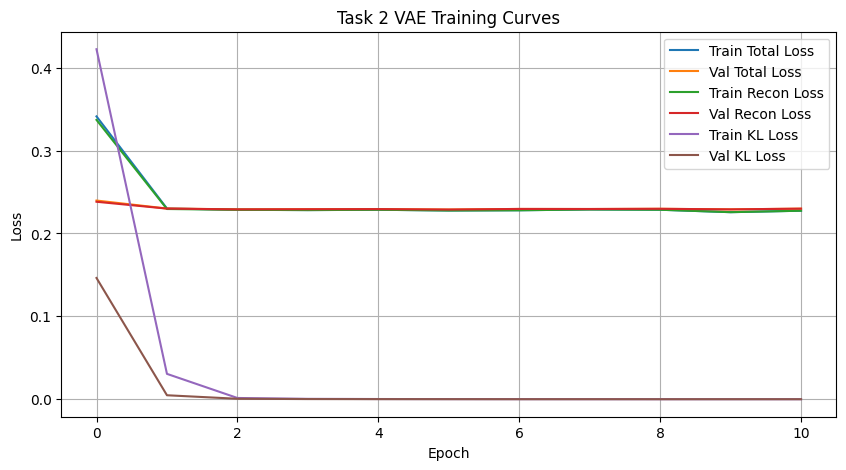

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Total Loss")
plt.plot(val_losses, label="Val Total Loss")
plt.plot(train_recon_losses, label="Train Recon Loss")
plt.plot(val_recon_losses, label="Val Recon Loss")
plt.plot(train_kl_losses, label="Train KL Loss")
plt.plot(val_kl_losses, label="Val KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 2 VAE Training Curves")
plt.legend()
plt.grid(True)
plt.show()

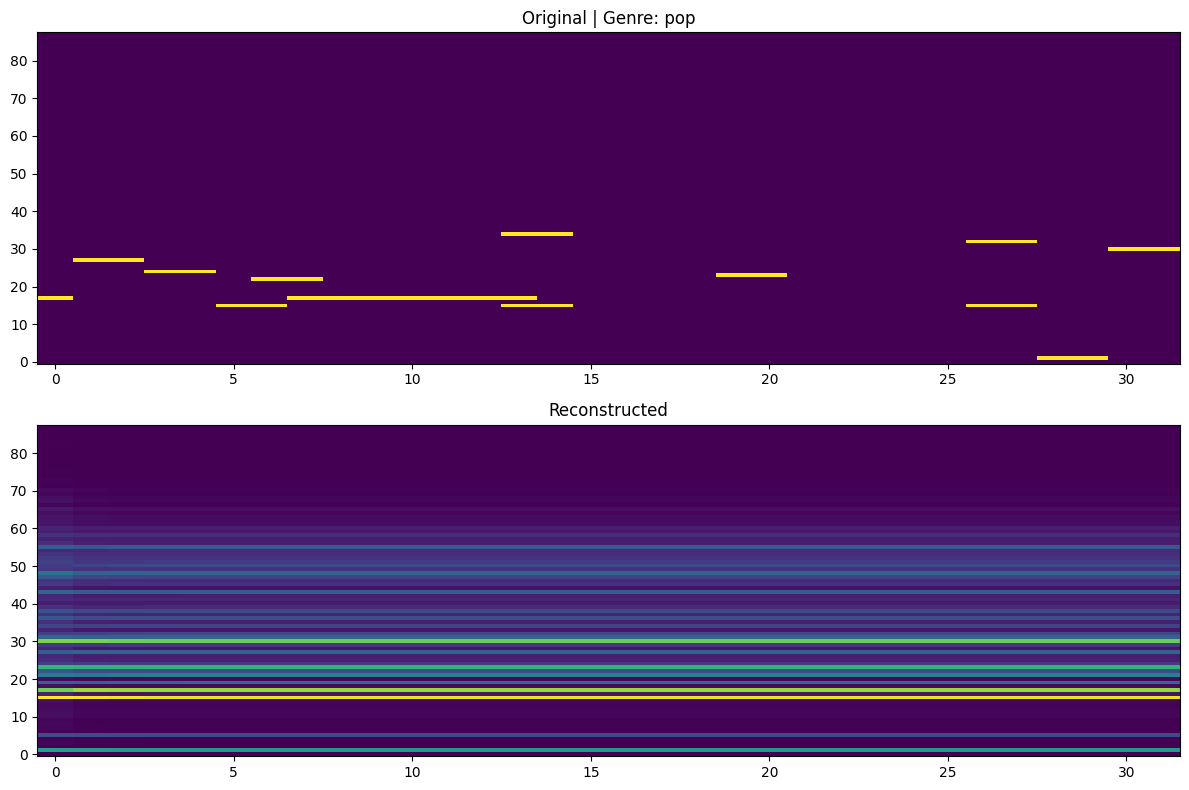

In [57]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

x_batch, g_batch = next(iter(test_loader))
x_batch = x_batch.to(device)
g_batch = g_batch.to(device)

with torch.no_grad():
    logits, mu, logvar = model(x_batch, g_batch)
    recon_batch = torch.sigmoid(logits)

original = x_batch[0].cpu().numpy()
reconstructed = recon_batch[0].cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].imshow(original.T, aspect='auto', origin='lower')
axes[0].set_title(f"Original | Genre: {id_to_genre[int(g_batch[0].cpu())]}")
axes[1].imshow(reconstructed.T, aspect='auto', origin='lower')
axes[1].set_title("Reconstructed")
plt.tight_layout()
plt.show()

In [58]:
def binarize_pianoroll(piano_roll, threshold=0.5, max_polyphony=6, min_keep_prob=0.35):
    pr = np.array(piano_roll, copy=True)
    binary_roll = np.zeros_like(pr, dtype=np.int32)

    for t in range(pr.shape[0]):
        row = pr[t]
        active = np.where(row >= threshold)[0]

        if len(active) == 0:
            best_idx = np.argmax(row)
            if row[best_idx] >= min_keep_prob:
                active = np.array([best_idx])

        if len(active) > max_polyphony:
            active = active[np.argsort(row[active])[-max_polyphony:]]

        binary_roll[t, active] = 1

    return binary_roll


def pianoroll_to_midi(piano_roll, output_path, fs=FS, min_pitch=MIN_PITCH,
                      threshold=0.5, max_polyphony=6, min_keep_prob=0.35):

    binary_roll = binarize_pianoroll(
        piano_roll,
        threshold=threshold,
        max_polyphony=max_polyphony,
        min_keep_prob=min_keep_prob
    )

    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)
    time_per_step = 1.0 / fs

    for pitch_idx in range(binary_roll.shape[1]):
        pitch = pitch_idx + min_pitch
        note_on = None

        for t in range(binary_roll.shape[0]):
            value = binary_roll[t, pitch_idx]

            if value == 1 and note_on is None:
                note_on = t * time_per_step

            elif value == 0 and note_on is not None:
                note_off = t * time_per_step
                if note_off > note_on:
                    instrument.notes.append(
                        pretty_midi.Note(
                            velocity=100,
                            pitch=pitch,
                            start=note_on,
                            end=note_off
                        )
                    )
                note_on = None

        if note_on is not None:
            note_off = binary_roll.shape[0] * time_per_step
            if note_off > note_on:
                instrument.notes.append(
                    pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=note_on,
                        end=note_off
                    )
                )

    pm.instruments.append(instrument)
    pm.write(output_path)

    return binary_roll

In [59]:
def generate_vae_samples(model, genre_id, num_samples=2, seq_len=SEQ_LEN):
    model.eval()
    genre_ids = torch.full((num_samples,), genre_id, dtype=torch.long, device=device)
    z = torch.randn(num_samples, LATENT_DIM, device=device)

    with torch.no_grad():
        samples = torch.sigmoid(model.decode(z, genre_ids, seq_len)).cpu().numpy()

    return samples


sampled_dir = os.path.join(OUTPUT_DIR, "generated_midis_task2")
os.makedirs(sampled_dir, exist_ok=True)

saved_paths = []

for genre_name, genre_id in genre_to_id.items():
    samples = generate_vae_samples(model, genre_id, num_samples=2)

    for i, sample in enumerate(samples):
        out_path = os.path.join(sampled_dir, f"{genre_name}_sample_{i+1}.mid")
        pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)
        saved_paths.append(out_path)

print("Saved", len(saved_paths), "generated MIDI files")
for p in saved_paths:
    print(p)

Saved 8 generated MIDI files
/content/outputs_task2_vae/generated_midis_task2/classical_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/classical_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/jazz_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/jazz_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/pop_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/pop_sample_2.mid
/content/outputs_task2_vae/generated_midis_task2/rock_sample_1.mid
/content/outputs_task2_vae/generated_midis_task2/rock_sample_2.mid


In [60]:
def latent_interpolation(model, x1, g1, x2, g2, steps=5, seq_len=SEQ_LEN):
    model.eval()

    with torch.no_grad():
        mu1, logvar1 = model.encode(x1, g1)
        mu2, logvar2 = model.encode(x2, g2)

        z1 = mu1
        z2 = mu2

        interpolations = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            logits = model.decode(z, g1, seq_len)
            sample = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            interpolations.append(sample)

    return interpolations


x1 = torch.tensor(test_data[0:1], dtype=torch.float32).to(device)
g1 = torch.tensor(test_labels[0:1], dtype=torch.long).to(device)

x2 = torch.tensor(test_data[10:11], dtype=torch.float32).to(device)
g2 = torch.tensor(test_labels[10:11], dtype=torch.long).to(device)

interp_samples = latent_interpolation(model, x1, g1, x2, g2, steps=5)

interp_dir = os.path.join(OUTPUT_DIR, "latent_interpolation")
os.makedirs(interp_dir, exist_ok=True)

for i, sample in enumerate(interp_samples):
    out_path = os.path.join(interp_dir, f"interp_{i+1}.mid")
    pianoroll_to_midi(sample, out_path, threshold=0.5, max_polyphony=6)

print("Saved interpolation samples to:", interp_dir)

Saved interpolation samples to: /content/outputs_task2_vae/latent_interpolation


In [61]:
def evaluate_vae(model, loader, device, pos_weight, beta):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.no_grad():
        for x, g in loader:
            x = x.to(device)
            g = g.to(device)

            logits, mu, logvar = model(x, g)
            loss, recon, kl = vae_loss_function(logits, x, mu, logvar, pos_weight, beta)

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


test_total, test_recon, test_kl = evaluate_vae(model, test_loader, device, pos_weight, BETA_MAX)

print("Test Total Loss:", round(test_total, 4))
print("Test Recon Loss:", round(test_recon, 4))
print("Test KL Loss:", round(test_kl, 4))

Test Total Loss: 0.232
Test Recon Loss: 0.2319
Test KL Loss: 0.0001


In [62]:
def compute_pitch_class_histogram(piano_roll, min_pitch=MIN_PITCH):
    piano_roll = (piano_roll > 0).astype(np.int32)
    pitch_activity = np.sum(piano_roll, axis=0).astype(np.float64)

    hist = np.zeros(12, dtype=np.float64)
    for i, value in enumerate(pitch_activity):
        midi_pitch = min_pitch + i
        pitch_class = midi_pitch % 12
        hist[pitch_class] += value

    total = np.sum(hist)
    if total > 0:
        hist /= total

    return hist


def histogram_distance(h1, h2):
    return np.sum(np.abs(h1 - h2))


def rhythm_diversity_score(piano_roll):
    piano_roll = (piano_roll > 0).astype(np.int32)
    note_counts = np.sum(piano_roll, axis=1)
    unique_durations = len(np.unique(note_counts))
    total_notes = np.sum(note_counts)
    if total_notes == 0:
        return 0.0
    return unique_durations / total_notes


def repetition_ratio(piano_roll, pattern_len=4):
    piano_roll = (piano_roll > 0).astype(np.int32)
    patterns = []

    for i in range(len(piano_roll) - pattern_len + 1):
        pattern = tuple(piano_roll[i:i+pattern_len].flatten())
        patterns.append(pattern)

    if len(patterns) == 0:
        return 0.0

    unique_patterns = len(set(patterns))
    repeated_patterns = len(patterns) - unique_patterns
    return repeated_patterns / len(patterns)

In [63]:
metric_rows = []

for genre_name, genre_id in genre_to_id.items():
    gen_seq = generate_vae_samples(model, genre_id=genre_id, num_samples=1)[0]
    gen_binary = binarize_pianoroll(gen_seq, threshold=0.5, max_polyphony=6)

    genre_indices = np.where(test_labels == genre_id)[0]
    if len(genre_indices) > 0:
        real_seq = test_data[genre_indices[0]]
    else:
        real_seq = test_data[0]

    real_hist = compute_pitch_class_histogram(real_seq)
    gen_hist = compute_pitch_class_histogram(gen_binary)

    metric_rows.append({
        "Genre": genre_name,
        "Pitch Histogram Distance": float(histogram_distance(real_hist, gen_hist)),
        "Rhythm Diversity": float(rhythm_diversity_score(gen_binary)),
        "Repetition Ratio": float(repetition_ratio(gen_binary))
    })

genre_metrics = pd.DataFrame(metric_rows)
print(genre_metrics)

       Genre  Pitch Histogram Distance  Rhythm Diversity  Repetition Ratio
0  classical                  1.862471          0.060606          0.931034
1       jazz                  1.636364          0.031250          0.965517
2        pop                  1.406061          0.060606          0.931034
3       rock                  1.702106          0.060606          0.931034


In [64]:
task2_results = pd.DataFrame([
    {
        "Model": "Task 2 Music VAE",
        "Test Total Loss": float(test_total),
        "Test Recon Loss": float(test_recon),
        "Test KL Loss": float(test_kl),
        "Mean Pitch Histogram Distance": float(genre_metrics["Pitch Histogram Distance"].mean()),
        "Mean Rhythm Diversity": float(genre_metrics["Rhythm Diversity"].mean()),
        "Mean Repetition Ratio": float(genre_metrics["Repetition Ratio"].mean())
    }
])

task2_csv = os.path.join(OUTPUT_DIR, "task2_metrics.csv")
task2_results.to_csv(task2_csv, index=False)

print(task2_results)
print("Saved:", task2_csv)

              Model  Test Total Loss  Test Recon Loss  Test KL Loss  \
0  Task 2 Music VAE         0.231958         0.231944      0.000136   

   Mean Pitch Histogram Distance  Mean Rhythm Diversity  Mean Repetition Ratio  
0                        1.65175               0.053267               0.939655  
Saved: /content/outputs_task2_vae/task2_metrics.csv


In [65]:
task1_csv = "/content/outputs_task1_fixed/task1_metrics.csv"
task2_csv = "/content/outputs_task2_vae/task2_metrics.csv"

if os.path.exists(task1_csv) and os.path.exists(task2_csv):
    task1_df = pd.read_csv(task1_csv)
    task2_df = pd.read_csv(task2_csv)

    clean_comparison = pd.DataFrame([
        {
            "Model": "Task 1 LSTM Autoencoder",
            "Main Loss": task1_df.loc[0, "Test Loss"],
            "KL Loss": "N/A",
            "Pitch Histogram Distance": task1_df.loc[0, "Pitch Histogram Distance"],
            "Rhythm Diversity": task1_df.loc[0, "Generated Rhythm Diversity"],
            "Repetition Ratio": task1_df.loc[0, "Generated Repetition Ratio"],
        },
        {
            "Model": "Task 2 Music VAE",
            "Main Loss": task2_df.loc[0, "Test Total Loss"],
            "KL Loss": task2_df.loc[0, "Test KL Loss"],
            "Pitch Histogram Distance": task2_df.loc[0, "Mean Pitch Histogram Distance"],
            "Rhythm Diversity": task2_df.loc[0, "Mean Rhythm Diversity"],
            "Repetition Ratio": task2_df.loc[0, "Mean Repetition Ratio"],
        }
    ])

    comparison_path = "/content/outputs_task2_vae/task1_vs_task2_comparison.csv"
    clean_comparison.to_csv(comparison_path, index=False)

    print(clean_comparison)
    print("Saved clean comparison to:", comparison_path)

else:
    print("Task 1 or Task 2 CSV not found.")
    print("Task 1 exists:", os.path.exists(task1_csv), task1_csv)
    print("Task 2 exists:", os.path.exists(task2_csv), task2_csv)

                     Model  Main Loss   KL Loss  Pitch Histogram Distance  \
0  Task 1 LSTM Autoencoder   0.493355       N/A                   2.00000   
1         Task 2 Music VAE   0.231958  0.000136                   1.65175   

   Rhythm Diversity  Repetition Ratio  
0          1.000000          0.983607  
1          0.053267          0.939655  
Saved clean comparison to: /content/outputs_task2_vae/task1_vs_task2_comparison.csv


In [66]:
!zip -r /content/task2_vae_outputs.zip /content/outputs_task2_vae > /dev/null
print("Created: /content/task2_vae_outputs.zip")

Created: /content/task2_vae_outputs.zip


**TASK-3**




In [67]:
# =========================
# =========================
from dataclasses import dataclass
import os
import math
import json
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

@dataclass
class Task3Config:
    data_path: str = "task3_tokenized_sequences.pt"
    output_dir: str = "/content/outputs_task3_transformer"

    pad_token_id: int = 0
    bos_token_id: int = 1
    eos_token_id: int = 2
    unk_token_id: int = 3

    max_seq_len: int = 256
    min_train_tokens: int = 32
    batch_size: int = 16
    num_workers: int = 2

    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 6
    d_ff: int = 1024
    dropout: float = 0.1
    label_smoothing: float = 0.05

    lr: float = 3e-4
    min_lr: float = 1e-5
    weight_decay: float = 1e-4
    epochs: int = 20
    warmup_steps: int = 400
    grad_clip: float = 1.0
    patience: int = 5

    gen_length: int = 384
    min_gen_len: int = 128
    prompt_len: int = 24
    temperature: float = 0.95
    top_k: int = 10
    top_p: float = 0.92
    repetition_penalty: float = 1.15
    no_repeat_ngram_size: int = 4

    seed: int = 42

cfg = Task3Config()
os.makedirs(cfg.output_dir, exist_ok=True)

# deterministic setup
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print(cfg)

Using device: cuda
Task3Config(data_path='task3_tokenized_sequences.pt', output_dir='/content/outputs_task3_transformer', pad_token_id=0, bos_token_id=1, eos_token_id=2, unk_token_id=3, max_seq_len=256, min_train_tokens=32, batch_size=16, num_workers=2, d_model=256, n_heads=8, n_layers=6, d_ff=1024, dropout=0.1, label_smoothing=0.05, lr=0.0003, min_lr=1e-05, weight_decay=0.0001, epochs=20, warmup_steps=400, grad_clip=1.0, patience=5, gen_length=384, min_gen_len=128, prompt_len=24, temperature=0.95, top_k=10, top_p=0.92, repetition_penalty=1.15, no_repeat_ngram_size=4, seed=42)


In [68]:
# -------------------------
# Event tokenization
# -------------------------
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]

def emit_time_shift(tokens, shift, max_shift=16):
    while shift > 0:
        step = min(shift, max_shift)
        tokens.append(f"TIME_SHIFT_{step}")
        shift -= step

def pianoroll_to_event_tokens(seq):
    """
    Converts a binary piano-roll sequence (T, P) into sparse note on/off + time-shift events.
    """
    seq = (seq > 0).astype(np.uint8)
    T, P = seq.shape

    tokens = []
    prev = np.zeros(P, dtype=np.uint8)
    pending_shift = 0

    for t in range(T):
        cur = seq[t]
        note_offs = np.where((prev == 1) & (cur == 0))[0].tolist()
        note_ons  = np.where((prev == 0) & (cur == 1))[0].tolist()

        if len(note_offs) == 0 and len(note_ons) == 0:
            pending_shift += 1
        else:
            if pending_shift > 0:
                emit_time_shift(tokens, pending_shift)
                pending_shift = 0

            for p in sorted(note_offs):
                tokens.append(f"NOTE_OFF_{p}")
            for p in sorted(note_ons):
                tokens.append(f"NOTE_ON_{p}")

        prev = cur.copy()

    if pending_shift > 0:
        emit_time_shift(tokens, pending_shift)

    for p in np.where(prev == 1)[0].tolist():
        tokens.append(f"NOTE_OFF_{p}")

    return tokens

def build_event_token_dataset(all_sequences, all_labels, min_freq=1):
    tokenized_events = []
    genre_ids = []

    for seq, genre in zip(all_sequences, all_labels):
        events = pianoroll_to_event_tokens(seq)
        tokenized_events.append(events)
        genre_ids.append(int(genre))

    counter = Counter()
    for events in tokenized_events:
        counter.update(events)

    vocab = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab[tok] = len(vocab)

    id_to_token = {i: t for t, i in vocab.items()}

    records = []
    for events, genre in zip(tokenized_events, genre_ids):
        token_ids = [vocab["<BOS>"]] + [vocab.get(ev, vocab["<UNK>"]) for ev in events] + [vocab["<EOS>"]]
        if len(token_ids) >= cfg.min_train_tokens:
            records.append({"tokens": token_ids, "genre": genre})

    return records, vocab, id_to_token

records, vocab, id_to_token = build_event_token_dataset(all_sequences, all_labels, min_freq=1)

cfg.pad_token_id = vocab["<PAD>"]
cfg.bos_token_id = vocab["<BOS>"]
cfg.eos_token_id = vocab["<EOS>"]
cfg.unk_token_id = vocab["<UNK>"]
cfg.vocab_size = len(vocab)
cfg.num_genres = int(len(np.unique(all_labels)))

payload = {"records": records, "vocab": vocab, "id_to_token": id_to_token}
torch.save(payload, cfg.data_path)

print("Saved tokenized dataset to:", cfg.data_path)
print("Records:", len(records))
print("Vocab size:", cfg.vocab_size)
print("Genres:", cfg.num_genres)

Saved tokenized dataset to: task3_tokenized_sequences.pt
Records: 1660
Vocab size: 172
Genres: 4


In [69]:
# -------------------------
# Dataset and model
# -------------------------
class MusicTokenDataset(Dataset):
    def __init__(self, records, max_seq_len, pad_token_id):
        self.records = records
        self.max_seq_len = max_seq_len
        self.pad_token_id = pad_token_id

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        tokens = rec["tokens"][: self.max_seq_len]
        genre = rec["genre"]
        return {
            "tokens": torch.tensor(tokens, dtype=torch.long),
            "genre": torch.tensor(genre, dtype=torch.long)
        }

def causal_lm_collate(batch, pad_token_id):
    token_seqs = [b["tokens"] for b in batch]
    genres = torch.stack([b["genre"] for b in batch])

    max_len = max(len(x) for x in token_seqs)
    padded = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)

    for i, seq in enumerate(token_seqs):
        padded[i, :len(seq)] = seq

    inputs = padded[:, :-1]
    targets = padded[:, 1:]
    padding_mask = inputs.eq(pad_token_id)

    return inputs, targets, genres, padding_mask

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MusicTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_genres,
        d_model=256,
        n_heads=8,
        n_layers=6,
        d_ff=1024,
        dropout=0.1,
        max_seq_len=512,
        pad_token_id=0
    ):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_id)
        self.genre_emb = nn.Embedding(num_genres, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_seq_len + 8)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, genre_ids, padding_mask=None):
        x = self.token_emb(input_ids)
        g = self.genre_emb(genre_ids).unsqueeze(1)
        x = x + g
        x = self.pos_enc(x)
        x = self.dropout(x)

        seq_len = input_ids.size(1)
        causal_mask = torch.triu(
            torch.full((seq_len, seq_len), float("-inf"), device=input_ids.device),
            diagonal=1
        )

        h = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)
        h = self.norm(h)
        logits = self.output_head(h)
        return logits

In [70]:
# -------------------------
# Data split, loaders, optimizer, training utilities
# -------------------------
payload = torch.load(cfg.data_path)
records = payload["records"]
vocab = payload["vocab"]
id_to_token = payload["id_to_token"]

records = [r for r in records if len(r["tokens"]) >= cfg.min_train_tokens]

rng = np.random.default_rng(cfg.seed)
by_genre = defaultdict(list)
for r in records:
    by_genre[int(r["genre"])].append(r)

train_records, val_records, test_records = [], [], []
for gid, recs in by_genre.items():
    recs = recs.copy()
    rng.shuffle(recs)
    n = len(recs)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_records.extend(recs[:train_end])
    val_records.extend(recs[train_end:val_end])
    test_records.extend(recs[val_end:])

rng.shuffle(train_records)
rng.shuffle(val_records)
rng.shuffle(test_records)

train_ds = MusicTokenDataset(train_records, cfg.max_seq_len, cfg.pad_token_id)
val_ds   = MusicTokenDataset(val_records, cfg.max_seq_len, cfg.pad_token_id)
test_ds  = MusicTokenDataset(test_records, cfg.max_seq_len, cfg.pad_token_id)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=lambda b: causal_lm_collate(b, cfg.pad_token_id)
)

print(f"Train / Val / Test sequences: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")

model = MusicTransformer(
    vocab_size=len(vocab),
    num_genres=cfg.num_genres,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    max_seq_len=cfg.max_seq_len,
    pad_token_id=cfg.pad_token_id
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    betas=(0.9, 0.95)
)

steps_per_epoch = max(1, len(train_loader))
total_steps = cfg.epochs * steps_per_epoch

def lr_lambda(step):
    step = max(1, step)
    if step < cfg.warmup_steps:
        return step / max(1, cfg.warmup_steps)
    progress = (step - cfg.warmup_steps) / max(1, total_steps - cfg.warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    floor = cfg.min_lr / cfg.lr
    return max(floor, cosine)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

criterion = nn.CrossEntropyLoss(
    ignore_index=cfg.pad_token_id,
    label_smoothing=cfg.label_smoothing
)

def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0

    for inputs, targets, genres, padding_mask in loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        genres = genres.to(DEVICE)
        padding_mask = padding_mask.to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(inputs, genres, padding_mask=padding_mask)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        valid_tokens = (targets != cfg.pad_token_id).sum().item()
        total_loss += loss.item() * valid_tokens
        total_tokens += valid_tokens

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()

    mean_nll = total_loss / max(1, total_tokens)
    ppl = float(math.exp(min(mean_nll, 20)))
    return mean_nll, ppl

Train / Val / Test sequences: 1326 / 166 / 168


/tmp/ipykernel_2563/844693562.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


{'epoch': 1, 'train_nll': 4.699246901833961, 'train_ppl': 109.8644026090091, 'val_nll': 3.9265153240563304, 'val_ppl': 50.72989207091015, 'lr': 6.225e-05}
{'epoch': 2, 'train_nll': 3.6495839416303197, 'train_ppl': 38.45866167181019, 'val_nll': 3.397521164379908, 'val_ppl': 29.88991595195077, 'lr': 0.0001245}
{'epoch': 3, 'train_nll': 3.2915438838158386, 'train_ppl': 26.88433792615689, 'val_nll': 3.161480820759424, 'val_ppl': 23.605525612749336, 'lr': 0.00018675}
{'epoch': 4, 'train_nll': 3.0446908329415145, 'train_ppl': 21.003536597344606, 'val_nll': 2.8663163027160112, 'val_ppl': 17.572168280864524, 'lr': 0.000249}
{'epoch': 5, 'train_nll': 2.8034553277318297, 'train_ppl': 16.50156669699264, 'val_nll': 2.6606063336049335, 'val_ppl': 14.304960047662203, 'lr': 0.0002998951057182598}
{'epoch': 6, 'train_nll': 2.6218540593469712, 'train_ppl': 13.761214054898133, 'val_nll': 2.5393435460609246, 'val_ppl': 12.671350082317725, 'lr': 0.0002955443589413994}
{'epoch': 7, 'train_nll': 2.495044862

/tmp/ipykernel_2563/844693562.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)



Best model: /content/outputs_task3_transformer/best_task3_transformer.pt
History saved to: /content/outputs_task3_transformer/task3_training_history.csv
Task 3 Test NLL: 2.1371
Task 3 Test Perplexity: 8.4752


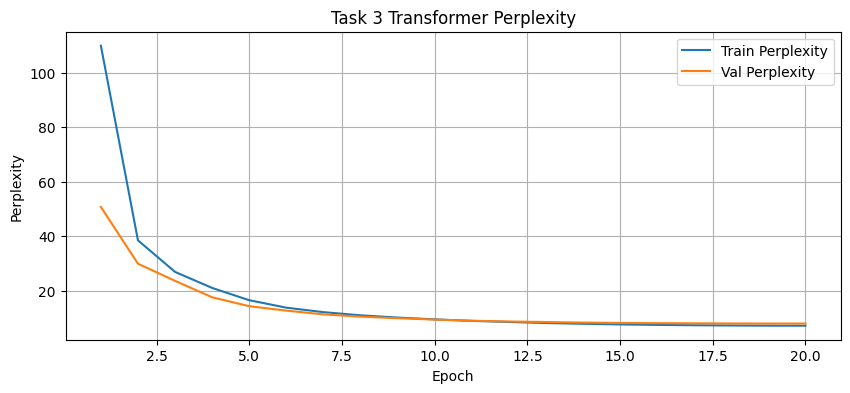

In [71]:
# -------------------------
# Training loop with checkpointing + perplexity report
# -------------------------
history = []
best_val_ppl = float("inf")
best_path = os.path.join(cfg.output_dir, "best_task3_transformer.pt")
patience_counter = 0

for epoch in range(1, cfg.epochs + 1):
    train_nll, train_ppl = run_epoch(model, train_loader, train=True)
    val_nll, val_ppl = run_epoch(model, val_loader, train=False)

    row = {
        "epoch": epoch,
        "train_nll": train_nll,
        "train_ppl": train_ppl,
        "val_nll": val_nll,
        "val_ppl": val_ppl,
        "lr": optimizer.param_groups[0]["lr"]
    }
    history.append(row)
    print(row)

    if val_ppl < best_val_ppl:
        best_val_ppl = val_ppl
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= cfg.patience:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history)
history_csv = os.path.join(cfg.output_dir, "task3_training_history.csv")
history_df.to_csv(history_csv, index=False)

best_model = MusicTransformer(
    vocab_size=len(vocab),
    num_genres=cfg.num_genres,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    max_seq_len=cfg.max_seq_len,
    pad_token_id=cfg.pad_token_id
).to(DEVICE)
best_model.load_state_dict(torch.load(best_path, map_location=DEVICE))

test_nll, test_ppl = run_epoch(best_model, test_loader, train=False)

print("\nBest model:", best_path)
print("History saved to:", history_csv)
print(f"Task 3 Test NLL: {test_nll:.4f}")
print(f"Task 3 Test Perplexity: {test_ppl:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_ppl"], label="Train Perplexity")
plt.plot(history_df["epoch"], history_df["val_ppl"], label="Val Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Task 3 Transformer Perplexity")
plt.grid(True)
plt.legend()
plt.show()

In [72]:
# -------------------------
# Autoregressive generation + MIDI export
# -------------------------
def top_k_top_p_filtering(logits, top_k=0, top_p=1.0):
    logits = logits.clone()

    if top_k > 0:
        top_k = min(top_k, logits.size(-1))
        values, _ = torch.topk(logits, top_k)
        cutoff = values[..., -1]
        logits[logits < cutoff] = -float("inf")

    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
        sorted_indices_to_remove[0] = False
        remove_ids = sorted_indices[sorted_indices_to_remove]
        logits[remove_ids] = -float("inf")

    return logits

def apply_no_repeat_ngram(logits, tokens, no_repeat_ngram_size):
    if no_repeat_ngram_size <= 1 or len(tokens) < no_repeat_ngram_size - 1:
        return logits

    prefix = tuple(tokens[-(no_repeat_ngram_size - 1):])
    banned = set()

    for i in range(len(tokens) - no_repeat_ngram_size + 1):
        ngram = tokens[i:i + no_repeat_ngram_size]
        if tuple(ngram[:-1]) == prefix:
            banned.add(ngram[-1])

    for tok in banned:
        logits[tok] = -float("inf")
    return logits

@torch.no_grad()
def generate_sequence(
    model,
    genre_id,
    prompt=None,
    max_new_tokens=384,
    min_new_tokens=128,
    temperature=1.0,
    top_k=10,
    top_p=0.92,
    repetition_penalty=1.15,
    no_repeat_ngram_size=4
):
    model.eval()

    if prompt is None or len(prompt) == 0:
        tokens = [cfg.bos_token_id]
    else:
        tokens = prompt[:]
        if tokens[0] != cfg.bos_token_id:
            tokens = [cfg.bos_token_id] + tokens

    start_len = len(tokens)

    for _ in range(max_new_tokens):
        x = torch.tensor(tokens[-cfg.max_seq_len:], dtype=torch.long, device=DEVICE).unsqueeze(0)
        g = torch.tensor([genre_id], dtype=torch.long, device=DEVICE)
        padding_mask = torch.zeros_like(x, dtype=torch.bool)

        logits = model(x, g, padding_mask=padding_mask)[0, -1]
        logits = logits / max(temperature, 1e-6)

        for t in set(tokens[-96:]):
            if logits[t] > 0:
                logits[t] /= repetition_penalty
            else:
                logits[t] *= repetition_penalty

        if (len(tokens) - start_len) < min_new_tokens:
            logits[cfg.eos_token_id] = -float("inf")

        logits = apply_no_repeat_ngram(logits, tokens, no_repeat_ngram_size)
        logits = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
        probs = F.softmax(logits, dim=-1)

        if torch.isnan(probs).any() or torch.isinf(probs).any() or probs.sum() <= 0:
            probs = torch.ones_like(probs) / probs.numel()

        next_token = torch.multinomial(probs, num_samples=1).item()
        tokens.append(next_token)
        if next_token == cfg.eos_token_id:
            break

    if tokens[-1] != cfg.eos_token_id:
        tokens.append(cfg.eos_token_id)

    return tokens

def build_prompt_for_genre(records, genre_id, prompt_len=24):
    candidates = [r for r in records if int(r["genre"]) == int(genre_id) and len(r["tokens"]) > prompt_len + 2]
    if len(candidates) == 0:
        return [cfg.bos_token_id]
    rec = max(candidates, key=lambda r: len(r["tokens"]))
    prompt = [t for t in rec["tokens"][:prompt_len] if t != cfg.eos_token_id]
    if len(prompt) == 0 or prompt[0] != cfg.bos_token_id:
        prompt = [cfg.bos_token_id] + prompt
    return prompt

def event_tokens_to_pianoroll(token_ids, id_to_token, pitch_dim=PITCH_DIM):
    active = np.zeros(pitch_dim, dtype=np.uint8)
    steps = []

    def push_step():
        steps.append(active.copy())

    for tid in token_ids:
        tok = id_to_token.get(int(tid), "<UNK>")
        if tok in ("<PAD>", "<BOS>", "<UNK>"):
            continue
        if tok == "<EOS>":
            break
        if tok.startswith("TIME_SHIFT_"):
            shift = int(tok.split("_")[-1])
            for _ in range(max(1, shift)):
                push_step()
        elif tok.startswith("NOTE_ON_"):
            p = int(tok.split("_")[-1])
            if 0 <= p < pitch_dim:
                active[p] = 1
        elif tok.startswith("NOTE_OFF_"):
            p = int(tok.split("_")[-1])
            if 0 <= p < pitch_dim:
                active[p] = 0

    if len(steps) == 0:
        steps.append(active.copy())

    pr = np.stack(steps, axis=0).astype(np.float32)
    return pr

task3_midi_dir = os.path.join(cfg.output_dir, "generated_midis_task3")
task3_json_dir = os.path.join(cfg.output_dir, "generated_json_task3")
os.makedirs(task3_midi_dir, exist_ok=True)
os.makedirs(task3_json_dir, exist_ok=True)

available_genres = sorted(list(set(int(r["genre"]) for r in train_records)))
genre_names_task3 = id_to_genre if "id_to_genre" in globals() else {gid: f"genre_{gid}" for gid in available_genres}

requested_genres = [available_genres[i % len(available_genres)] for i in range(10)]
task3_samples = []

for i, gid in enumerate(requested_genres, start=1):
    prompt = build_prompt_for_genre(train_records, gid, prompt_len=cfg.prompt_len)
    seq = generate_sequence(
        best_model,
        genre_id=gid,
        prompt=prompt,
        max_new_tokens=cfg.gen_length,
        min_new_tokens=cfg.min_gen_len,
        temperature=cfg.temperature,
        top_k=cfg.top_k,
        top_p=cfg.top_p,
        repetition_penalty=cfg.repetition_penalty,
        no_repeat_ngram_size=cfg.no_repeat_ngram_size,
    )

    pr = event_tokens_to_pianoroll(seq, id_to_token, pitch_dim=PITCH_DIM)
    genre_name = genre_names_task3.get(gid, f"genre_{gid}")
    midi_path = os.path.join(task3_midi_dir, f"task3_sample_{i:02d}_{genre_name}.mid")
    json_path = os.path.join(task3_json_dir, f"task3_sample_{i:02d}_{genre_name}.json")

    pianoroll_to_midi(pr, midi_path, fs=FS, min_pitch=MIN_PITCH, threshold=0.5, max_polyphony=6)

    record = {
        "sample_id": i,
        "genre_id": int(gid),
        "genre_name": genre_name,
        "prompt_length": len(prompt),
        "num_tokens": len(seq),
        "midi_path": midi_path,
        "tokens": seq,
        "token_text": [id_to_token.get(t, "<UNK>") for t in seq]
    }
    task3_samples.append(record)

    with open(json_path, "w") as f:
        json.dump(record, f, indent=2)

task3_samples_df = pd.DataFrame([
    {
        "sample_id": s["sample_id"],
        "genre": s["genre_name"],
        "prompt_length": s["prompt_length"],
        "num_tokens": s["num_tokens"],
        "midi_path": s["midi_path"],
    }
    for s in task3_samples
])

print("Generated MIDI files:", len(task3_samples_df))
task3_samples_df

Generated MIDI files: 10


,sample_id,genre,prompt_length,num_tokens,midi_path
0,1,classical,24,154,/content/outputs_task3_transformer/generated_m...
1,2,jazz,24,155,/content/outputs_task3_transformer/generated_m...
2,3,pop,24,155,/content/outputs_task3_transformer/generated_m...
3,4,rock,24,153,/content/outputs_task3_transformer/generated_m...
4,5,classical,24,153,/content/outputs_task3_transformer/generated_m...
5,6,jazz,24,153,/content/outputs_task3_transformer/generated_m...
6,7,pop,24,156,/content/outputs_task3_transformer/generated_m...
7,8,rock,24,153,/content/outputs_task3_transformer/generated_m...
8,9,classical,24,153,/content/outputs_task3_transformer/generated_m...
9,10,jazz,24,153,/content/outputs_task3_transformer/generated_m...


In [73]:
import os, glob
import pandas as pd

generated_dirs = [
    "/content/outputs_task1_fixed",
    "/content/outputs_task2_vae",
    "/content/outputs_task3",
    "/content/outputs_task3_transformer",
    "/content/outputs_task4_rlhf"
]

generated_midis = []

for d in generated_dirs:
    if os.path.exists(d):
        generated_midis.extend(glob.glob(os.path.join(d, "**/*.mid"), recursive=True))

generated_midis = sorted(list(set(generated_midis)))

generated_table = pd.DataFrame({
    "index": range(len(generated_midis)),
    "midi_path": generated_midis
})

display(generated_table)

print("Generated MIDI files found:", len(generated_midis))

,index,midi_path
0,0,/content/outputs_task1_fixed/generated_midis_t...
1,1,/content/outputs_task1_fixed/generated_midis_t...
2,2,/content/outputs_task1_fixed/generated_midis_t...
3,3,/content/outputs_task1_fixed/generated_midis_t...
4,4,/content/outputs_task1_fixed/generated_midis_t...
5,5,/content/outputs_task1_fixed/generated_midis_t...
6,6,/content/outputs_task1_fixed/generated_midis_t...
7,7,/content/outputs_task1_fixed/generated_midis_t...
8,8,/content/outputs_task1_fixed/generated_midis_t...
9,9,/content/outputs_task1_fixed/generated_midis_t...


Generated MIDI files found: 33


In [74]:
import pretty_midi
import numpy as np
from IPython.display import Audio, display

def listen_midi(index, fs=22050):
    midi_path = generated_midis[index]
    print("Playing index:", index)
    print("File:", midi_path)

    midi_data = pretty_midi.PrettyMIDI(midi_path)
    audio = midi_data.synthesize(fs=fs)

    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    display(Audio(audio, rate=fs))

In [75]:
listen_midi(3)

Playing index: 3
File: /content/outputs_task1_fixed/generated_midis_task1_reconstructed/reconstructed_4.mid


**Task-4**



**Reinforcement Learning
Human Preference Tuning**




In [76]:
import os, json, random, copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_BEFORE_DIR = os.path.join(TASK4_DIR, "before_rl_midis")
TASK4_AFTER_DIR = os.path.join(TASK4_DIR, "after_rl_midis")
TASK4_SURVEY_DIR = os.path.join(TASK4_DIR, "survey_results")
TASK4_MODEL_DIR = os.path.join(TASK4_DIR, "models")
TASK4_PLOTS_DIR = os.path.join(TASK4_DIR, "plots")

for d in [
    TASK4_DIR,
    TASK4_BEFORE_DIR,
    TASK4_AFTER_DIR,
    TASK4_SURVEY_DIR,
    TASK4_MODEL_DIR,
    TASK4_PLOTS_DIR
]:
    os.makedirs(d, exist_ok=True)

print("Task 4 folders created.")

Task 4 folders created.


In [77]:
required_task3_items = [
    "model",
    "generate_sequence",
    "build_prompt_for_genre",
    "train_records",
    "available_genres",
    "id_to_genre",
    "id_to_token",
    "event_tokens_to_pianoroll",
    "pianoroll_to_midi",
    "cfg",
    "DEVICE",
    "PITCH_DIM",
    "FS",
    "MIN_PITCH"
]

missing = [x for x in required_task3_items if x not in globals()]

if missing:
    print("Missing variables/functions:")
    print(missing)
    print("Rerun Task 3 cells before continuing Task 4.")
else:
    print("All required Task 3 items exist. Continue.")

All required Task 3 items exist. Continue.


In [78]:
policy_model = copy.deepcopy(model).to(DEVICE)
policy_model.train()

ref_model = copy.deepcopy(model).to(DEVICE)
ref_model.eval()

for p in ref_model.parameters():
    p.requires_grad = False

print("Policy model and reference model ready.")

Policy model and reference model ready.


In [79]:
before_samples = []

num_before_samples = 10
genre_ids = list(available_genres)

for i in range(1, num_before_samples + 1):
    genre_id = random.choice(genre_ids)
    genre_name = id_to_genre.get(genre_id, f"genre_{genre_id}")

    prompt = build_prompt_for_genre(
        train_records,
        genre_id,
        prompt_len=cfg.prompt_len
    )

    with torch.no_grad():
        token_seq = generate_sequence(
            policy_model,
            genre_id=genre_id,
            prompt=prompt,
            max_new_tokens=160,
            min_new_tokens=64,
            temperature=cfg.temperature,
            top_k=cfg.top_k,
            top_p=cfg.top_p,
            repetition_penalty=cfg.repetition_penalty,
            no_repeat_ngram_size=cfg.no_repeat_ngram_size,
        )

    pr = event_tokens_to_pianoroll(
        token_seq,
        id_to_token,
        pitch_dim=PITCH_DIM
    )

    midi_path = os.path.join(
        TASK4_BEFORE_DIR,
        f"before_rl_sample_{i:02d}_{genre_name}.mid"
    )

    pianoroll_to_midi(
        pr,
        midi_path,
        fs=FS,
        min_pitch=MIN_PITCH,
        threshold=0.5,
        max_polyphony=6
    )

    before_samples.append({
        "sample_id": i,
        "stage": "before_rl",
        "genre_id": int(genre_id),
        "genre_name": genre_name,
        "midi_path": midi_path,
        "token_sequence": json.dumps([int(x) for x in token_seq])
    })

before_df = pd.DataFrame(before_samples)

before_csv = os.path.join(TASK4_DIR, "before_rl_samples.csv")
before_df.to_csv(before_csv, index=False)

display(before_df[["sample_id", "genre_name", "midi_path"]])
print("Saved before-RL sample list:", before_csv)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


,sample_id,genre_name,midi_path
0,1,classical,/content/outputs_task4_rlhf/before_rl_midis/be...
1,2,classical,/content/outputs_task4_rlhf/before_rl_midis/be...
2,3,pop,/content/outputs_task4_rlhf/before_rl_midis/be...
3,4,jazz,/content/outputs_task4_rlhf/before_rl_midis/be...
4,5,jazz,/content/outputs_task4_rlhf/before_rl_midis/be...
5,6,jazz,/content/outputs_task4_rlhf/before_rl_midis/be...
6,7,classical,/content/outputs_task4_rlhf/before_rl_midis/be...
7,8,classical,/content/outputs_task4_rlhf/before_rl_midis/be...
8,9,rock,/content/outputs_task4_rlhf/before_rl_midis/be...
9,10,classical,/content/outputs_task4_rlhf/before_rl_midis/be...


Saved before-RL sample list: /content/outputs_task4_rlhf/before_rl_samples.csv


In [80]:
survey_template_rows = []

for _, row in before_df.iterrows():
    for participant_id in range(1, 11):
        survey_template_rows.append({
            "participant_id": f"P{participant_id:02d}",
            "sample_id": row["sample_id"],
            "genre_name": row["genre_name"],
            "coherence": "",
            "rhythm": "",
            "creativity": "",
            "genre_fit": "",
            "overall": "",
            "comments": ""
        })

survey_template = pd.DataFrame(survey_template_rows)

survey_template_path = os.path.join(
    TASK4_SURVEY_DIR,
    "human_survey_template.csv"
)

survey_template.to_csv(survey_template_path, index=False)

display(survey_template.head(15))
print("Saved survey template:", survey_template_path)

,participant_id,sample_id,genre_name,coherence,rhythm,creativity,genre_fit,overall,comments
0,P01,1,classical,,,,,,
1,P02,1,classical,,,,,,
2,P03,1,classical,,,,,,
3,P04,1,classical,,,,,,
4,P05,1,classical,,,,,,
5,P06,1,classical,,,,,,
6,P07,1,classical,,,,,,
7,P08,1,classical,,,,,,
8,P09,1,classical,,,,,,
9,P10,1,classical,,,,,,


Saved survey template: /content/outputs_task4_rlhf/survey_results/human_survey_template.csv


In [81]:
import os, glob
import numpy as np
import pretty_midi
from scipy.io.wavfile import write

BEFORE_MIDI_DIR = "/content/outputs_task4_rlhf/before_rl_midis"
BEFORE_AUDIO_DIR = "/content/outputs_task4_rlhf/before_rl_audio"

os.makedirs(BEFORE_AUDIO_DIR, exist_ok=True)

before_midis = sorted(glob.glob(os.path.join(BEFORE_MIDI_DIR, "*.mid")))

print("MIDI files found:", len(before_midis))

for midi_path in before_midis:
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        audio = midi_data.synthesize(fs=22050)

        # Normalize audio
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        # Convert to int16 WAV format
        audio_int16 = np.int16(audio * 32767)

        base_name = os.path.splitext(os.path.basename(midi_path))[0]
        wav_path = os.path.join(BEFORE_AUDIO_DIR, base_name + ".wav")

        write(wav_path, 22050, audio_int16)

        print("Saved:", wav_path)

    except Exception as e:
        print("Error converting:", midi_path)
        print(e)

MIDI files found: 10
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_01_classical.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_02_classical.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_03_pop.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_04_jazz.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_05_jazz.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_06_jazz.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_07_classical.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_08_classical.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_09_rock.wav
Saved: /content/outputs_task4_rlhf/before_rl_audio/before_rl_sample_10_classical.wav


In [82]:
import os

csv_path = "/content/outputs_task4_rlhf/survey_results/human_survey.csv"

print("Exists:", os.path.exists(csv_path))

Exists: False


In [83]:
import glob
import os

csv_files = sorted(glob.glob("/content/outputs*/**/*.csv", recursive=True))

print("Total CSV files in project output folders:", len(csv_files))

for i, path in enumerate(csv_files):
    print(i, path)

Total CSV files in project output folders: 6
0 /content/outputs_task1_fixed/task1_metrics.csv
1 /content/outputs_task2_vae/task1_vs_task2_comparison.csv
2 /content/outputs_task2_vae/task2_metrics.csv
3 /content/outputs_task3_transformer/task3_training_history.csv
4 /content/outputs_task4_rlhf/before_rl_samples.csv
5 /content/outputs_task4_rlhf/survey_results/human_survey_template.csv


In [84]:
import os
import shutil

paths_to_delete = [
    "/content/outputs_task4_rlhf/survey_results/human_survey.csv",
    "/content/outputs_task4_rlhf/survey_results/aggregated_human_rewards.csv",
    "/content/outputs_task4_rlhf/rl_training_data.csv",
    "/content/outputs_task4_rlhf/task4_rl_training_history.csv",
    "/content/outputs_task4_rlhf/after_rl_samples.csv",
    "/content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt",
    "/content/outputs_task4_rlhf/plots/task4_rl_loss_curve.png",
    "/content/outputs_task4_rlhf/plots/task4_before_after_human_score.png",
    "/content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv",
]

folders_to_delete = [
    "/content/outputs_task4_rlhf/after_rl_midis",
    "/content/outputs_task4_rlhf/after_rl_audio",
]

for path in paths_to_delete:
    if os.path.exists(path):
        os.remove(path)
        print("Deleted file:", path)
    else:
        print("File not found, skipped:", path)

for folder in folders_to_delete:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print("Deleted folder:", folder)
    else:
        print("Folder not found, skipped:", folder)

print("Old wrong survey-based Task 4 work deleted.")

File not found, skipped: /content/outputs_task4_rlhf/survey_results/human_survey.csv
File not found, skipped: /content/outputs_task4_rlhf/survey_results/aggregated_human_rewards.csv
File not found, skipped: /content/outputs_task4_rlhf/rl_training_data.csv
File not found, skipped: /content/outputs_task4_rlhf/task4_rl_training_history.csv
File not found, skipped: /content/outputs_task4_rlhf/after_rl_samples.csv
File not found, skipped: /content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt
File not found, skipped: /content/outputs_task4_rlhf/plots/task4_rl_loss_curve.png
File not found, skipped: /content/outputs_task4_rlhf/plots/task4_before_after_human_score.png
File not found, skipped: /content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv
Deleted folder: /content/outputs_task4_rlhf/after_rl_midis
Folder not found, skipped: /content/outputs_task4_rlhf/after_rl_audio
Old wrong survey-based Task 4 work deleted.


In [85]:
import glob

task4_csv_files = sorted(glob.glob("/content/outputs_task4_rlhf/**/*.csv", recursive=True))

print("Remaining Task 4 CSV files:", len(task4_csv_files))

for i, path in enumerate(task4_csv_files):
    print(i, path)

Remaining Task 4 CSV files: 2
0 /content/outputs_task4_rlhf/before_rl_samples.csv
1 /content/outputs_task4_rlhf/survey_results/human_survey_template.csv


In [86]:
from google.colab import files

uploaded = files.upload()

Saving CSE425 Music Generation Listening Survey (Responses) - Form Responses 1 (1).csv to CSE425 Music Generation Listening Survey (Responses) - Form Responses 1 (1).csv


In [87]:
import os
import re
import pandas as pd
import numpy as np

# Get uploaded CSV file name automatically
uploaded_csv = list(uploaded.keys())[0]
google_csv_path = "/content/" + uploaded_csv

form_df = pd.read_csv(google_csv_path)

print("Loaded:", google_csv_path)
print("Number of Google Form responses:", len(form_df))
print("\nColumns found:")
for col in form_df.columns:
    print(col)

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_SURVEY_DIR = "/content/outputs_task4_rlhf/survey_results"
os.makedirs(TASK4_SURVEY_DIR, exist_ok=True)

before_csv = os.path.join(TASK4_DIR, "before_rl_samples.csv")
before_df = pd.read_csv(before_csv)

sample_to_genre = dict(zip(before_df["sample_id"], before_df["genre_name"]))

rating_map = {
    "coherence": ["coherence"],
    "rhythm": ["rhythm"],
    "creativity": ["creativity"],
    "genre_fit": ["genre fit", "genre_fit", "genrefit"],
    "overall": ["overall quality", "overall"]
}

def clean_rating_value(value):
    if pd.isna(value):
        return np.nan

    value_str = str(value).strip()
    match = re.search(r"[1-5]", value_str)

    if match:
        return int(match.group())

    return np.nan

rows = []

for response_index, response in form_df.iterrows():

    participant_id = None

    for col in form_df.columns:
        if "participant" in col.lower():
            participant_id = response[col]
            break

    if pd.isna(participant_id) or participant_id is None:
        participant_id = f"P{response_index + 1:02d}"

    for sample_id in range(1, 11):
        output_row = {
            "participant_id": participant_id,
            "sample_id": sample_id,
            "genre_name": sample_to_genre.get(sample_id, f"sample_{sample_id}"),
            "coherence": np.nan,
            "rhythm": np.nan,
            "creativity": np.nan,
            "genre_fit": np.nan,
            "overall": np.nan,
            "comments": ""
        }

        for clean_name, possible_names in rating_map.items():
            matched_col = None

            for col in form_df.columns:
                col_lower = col.lower()

                sample_match = (
                    f"sample {sample_id}" in col_lower or
                    f"sample_{sample_id}" in col_lower or
                    f"sample{sample_id}" in col_lower
                )

                metric_match = any(name in col_lower for name in possible_names)

                if sample_match and metric_match:
                    matched_col = col
                    break

            if matched_col is not None:
                output_row[clean_name] = clean_rating_value(response[matched_col])

        rows.append(output_row)

survey_clean = pd.DataFrame(rows)

rating_cols = ["coherence", "rhythm", "creativity", "genre_fit", "overall"]

# Remove empty rows
survey_clean = survey_clean.dropna(subset=rating_cols, how="all")

human_survey_path = os.path.join(TASK4_SURVEY_DIR, "human_survey.csv")
survey_clean.to_csv(human_survey_path, index=False)

display(survey_clean.head(20))

print("Rows saved:", len(survey_clean))
print("Expected rows = number of responses × 10 samples")
print("Saved new human survey:", human_survey_path)

Loaded: /content/CSE425 Music Generation Listening Survey (Responses) - Form Responses 1 (1).csv
Number of Google Form responses: 12

Columns found:
Timestamp
Sample 1 Rating [Coherence]
Sample 1 Rating [Rhythm]
Sample 1 Rating [Creativity]
Sample 1 Rating [Genre Fit]
Sample 1 Rating [Overall Quality]
Sample 2 Rating [Coherence]
Sample 2 Rating [Rhythm]
Sample 2 Rating [Creativity]
Sample 2 Rating [Genre Fit]
Sample 2 Rating [Overall Quality]
Sample 3 Rating [Coherence]
Sample 3 Rating [Rhythm]
Sample 3 Rating [Creativity]
Sample 3 Rating [Genre Fit]
Sample 3 Rating [Overall Quality]
Sample 4 Rating [Coherence]
Sample 4 Rating [Rhythm]
Sample 4 Rating [Creativity]
Sample 4 Rating [Genre Fit]
Sample 4 Rating [Overall Quality]
Sample 5 Rating [Coherence]
Sample 5 Rating [Rhythm]
Sample 5 Rating [Creativity]
Sample 5 Rating [Genre Fit]
Sample 5 Rating [Overall Quality]
Sample 6 Rating [Coherence]
Sample 6 Rating [Rhythm]
Sample 6 Rating [Creativity]
Sample 6 Rating [Genre Fit]
Sample 6 Ra

,participant_id,sample_id,genre_name,coherence,rhythm,creativity,genre_fit,overall,comments
0,P01,1,classical,4,4,3,4,4,
1,P01,2,classical,4,4,3,4,4,
2,P01,3,pop,2,2,1,1,1,
3,P01,4,jazz,2,2,1,2,2,
4,P01,5,jazz,2,2,1,2,2,
5,P01,6,jazz,2,3,1,2,2,
6,P01,7,classical,4,4,4,4,4,
7,P01,8,classical,5,5,4,5,4,
8,P01,9,rock,1,1,1,1,1,
9,P01,10,classical,3,2,2,3,3,


Rows saved: 120
Expected rows = number of responses × 10 samples
Saved new human survey: /content/outputs_task4_rlhf/survey_results/human_survey.csv


In [88]:
import os
import pandas as pd
import numpy as np

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_SURVEY_DIR = "/content/outputs_task4_rlhf/survey_results"

survey_path = os.path.join(TASK4_SURVEY_DIR, "human_survey.csv")
survey_df = pd.read_csv(survey_path)

rating_cols = ["coherence", "rhythm", "creativity", "genre_fit", "overall"]

for col in rating_cols:
    survey_df[col] = pd.to_numeric(survey_df[col], errors="coerce")

survey_df["human_score"] = survey_df[rating_cols].mean(axis=1)

sample_rewards = (
    survey_df
    .groupby(["sample_id", "genre_name"])["human_score"]
    .mean()
    .reset_index()
)

sample_rewards["reward"] = (sample_rewards["human_score"] - 1.0) / 4.0
sample_rewards["reward"] = sample_rewards["reward"].clip(0.0, 1.0)

reward_csv = os.path.join(TASK4_SURVEY_DIR, "aggregated_human_rewards.csv")
sample_rewards.to_csv(reward_csv, index=False)

display(sample_rewards)
print("Saved rewards:", reward_csv)

,sample_id,genre_name,human_score,reward
0,1,classical,3.166667,0.541667
1,2,classical,3.316667,0.579167
2,3,pop,2.583333,0.395833
3,4,jazz,2.716667,0.429167
4,5,jazz,3.166667,0.541667
5,6,jazz,3.083333,0.520833
6,7,classical,3.850000,0.712500
7,8,classical,4.433333,0.858333
8,9,rock,2.233333,0.308333
9,10,classical,3.600000,0.650000


Saved rewards: /content/outputs_task4_rlhf/survey_results/aggregated_human_rewards.csv


In [89]:
before_csv = os.path.join(TASK4_DIR, "before_rl_samples.csv")
before_df = pd.read_csv(before_csv)

rl_data = before_df.merge(
    sample_rewards[["sample_id", "human_score", "reward"]],
    on="sample_id",
    how="inner"
)

rl_data_path = os.path.join(TASK4_DIR, "rl_training_data.csv")
rl_data.to_csv(rl_data_path, index=False)

display(rl_data[["sample_id", "genre_name", "human_score", "reward", "midi_path"]])
print("Rows:", len(rl_data))
print("Saved RL training data:", rl_data_path)

,sample_id,genre_name,human_score,reward,midi_path
0,1,classical,3.166667,0.541667,/content/outputs_task4_rlhf/before_rl_midis/be...
1,2,classical,3.316667,0.579167,/content/outputs_task4_rlhf/before_rl_midis/be...
2,3,pop,2.583333,0.395833,/content/outputs_task4_rlhf/before_rl_midis/be...
3,4,jazz,2.716667,0.429167,/content/outputs_task4_rlhf/before_rl_midis/be...
4,5,jazz,3.166667,0.541667,/content/outputs_task4_rlhf/before_rl_midis/be...
5,6,jazz,3.083333,0.520833,/content/outputs_task4_rlhf/before_rl_midis/be...
6,7,classical,3.850000,0.712500,/content/outputs_task4_rlhf/before_rl_midis/be...
7,8,classical,4.433333,0.858333,/content/outputs_task4_rlhf/before_rl_midis/be...
8,9,rock,2.233333,0.308333,/content/outputs_task4_rlhf/before_rl_midis/be...
9,10,classical,3.600000,0.650000,/content/outputs_task4_rlhf/before_rl_midis/be...


Rows: 10
Saved RL training data: /content/outputs_task4_rlhf/rl_training_data.csv


In [109]:
import json
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class HumanPreferenceDataset(Dataset):
    def __init__(self, rl_dataframe):
        self.rows = rl_dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]

        token_ids = json.loads(row["token_sequence"])
        genre_id = int(row["genre_id"])
        reward = float(row["reward"])

        return {
            "tokens": torch.tensor(token_ids, dtype=torch.long),
            "genre_id": torch.tensor(genre_id, dtype=torch.long),
            "reward": torch.tensor(reward, dtype=torch.float32),
            "sample_id": int(row["sample_id"])
        }


def rl_collate(batch):
    max_len = max(len(item["tokens"]) for item in batch)

    tokens = torch.full(
        (len(batch), max_len),
        cfg.pad_token_id,
        dtype=torch.long
    )

    genres = torch.stack([item["genre_id"] for item in batch])
    rewards = torch.stack([item["reward"] for item in batch])
    sample_ids = [item["sample_id"] for item in batch]

    for i, item in enumerate(batch):
        seq = item["tokens"]
        tokens[i, :len(seq)] = seq

    return tokens, genres, rewards, sample_ids


def sequence_logprob(model, token_batch, genre_batch, pad_token_id):
    input_ids = token_batch[:, :-1]
    target_ids = token_batch[:, 1:]

    padding_mask = input_ids.eq(pad_token_id)

    logits = model(
        input_ids=input_ids,
        genre_ids=genre_batch,
        padding_mask=padding_mask
    )

    log_probs = F.log_softmax(logits, dim=-1)

    token_log_probs = log_probs.gather(
        dim=-1,
        index=target_ids.unsqueeze(-1)
    ).squeeze(-1)

    valid_mask = target_ids.ne(pad_token_id)
    token_log_probs = token_log_probs * valid_mask

    seq_log_probs = token_log_probs.sum(dim=1)
    seq_lengths = valid_mask.sum(dim=1).clamp(min=1)

    return seq_log_probs / seq_lengths


rl_dataset = HumanPreferenceDataset(rl_data)

rl_loader = DataLoader(
    rl_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=rl_collate
)

print("RL training samples:", len(rl_dataset))
print("sequence_logprob created successfully.")

RL training samples: 10
sequence_logprob created successfully.


In [110]:
import numpy as np
import pandas as pd
import torch
import os

policy_model.train()
ref_model.eval()

for p in ref_model.parameters():
    p.requires_grad = False

rl_optimizer = torch.optim.AdamW(
    policy_model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

RL_EPOCHS = 15
KL_COEF = 0.02
GRAD_CLIP = 1.0

reward_baseline = float(rl_data["reward"].mean())

rl_history = []

for epoch in range(1, RL_EPOCHS + 1):
    epoch_losses = []
    epoch_pg_losses = []
    epoch_kl_losses = []
    epoch_rewards = []

    for token_batch, genre_batch, reward_batch, sample_ids in rl_loader:
        token_batch = token_batch.to(DEVICE)
        genre_batch = genre_batch.to(DEVICE)
        reward_batch = reward_batch.to(DEVICE)

        policy_logp = sequence_logprob(
            policy_model,
            token_batch,
            genre_batch,
            cfg.pad_token_id
        )

        with torch.no_grad():
            ref_logp = sequence_logprob(
                ref_model,
                token_batch,
                genre_batch,
                cfg.pad_token_id
            )

        advantage = reward_batch - reward_baseline

        policy_gradient_loss = -(advantage * policy_logp).mean()
        kl_penalty = ((policy_logp - ref_logp) ** 2).mean()

        loss = policy_gradient_loss + KL_COEF * kl_penalty

        rl_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), GRAD_CLIP)
        rl_optimizer.step()

        epoch_losses.append(float(loss.item()))
        epoch_pg_losses.append(float(policy_gradient_loss.item()))
        epoch_kl_losses.append(float(kl_penalty.item()))
        epoch_rewards.append(float(reward_batch.mean().item()))

    row = {
        "epoch": epoch,
        "mean_loss": np.mean(epoch_losses),
        "mean_policy_gradient_loss": np.mean(epoch_pg_losses),
        "mean_kl_penalty": np.mean(epoch_kl_losses),
        "mean_reward": np.mean(epoch_rewards)
    }

    rl_history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {row['mean_loss']:.4f} | "
        f"PG Loss: {row['mean_policy_gradient_loss']:.4f} | "
        f"KL: {row['mean_kl_penalty']:.4f} | "
        f"Reward: {row['mean_reward']:.4f}"
    )

rl_history_df = pd.DataFrame(rl_history)

rl_history_path = os.path.join(
    TASK4_DIR,
    "task4_rl_training_history.csv"
)

rl_history_df.to_csv(rl_history_path, index=False)

display(rl_history_df)
print("Saved RL training history:", rl_history_path)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 01 | Loss: 0.0522 | PG Loss: 0.0511 | KL: 0.0570 | Reward: 0.5537
Epoch 02 | Loss: 0.0424 | PG Loss: 0.0415 | KL: 0.0452 | Reward: 0.5538
Epoch 03 | Loss: 0.0335 | PG Loss: 0.0323 | KL: 0.0616 | Reward: 0.5537
Epoch 04 | Loss: 0.0295 | PG Loss: 0.0277 | KL: 0.0900 | Reward: 0.5537
Epoch 05 | Loss: 0.0236 | PG Loss: 0.0210 | KL: 0.1324 | Reward: 0.5537
Epoch 06 | Loss: 0.0143 | PG Loss: 0.0096 | KL: 0.2358 | Reward: 0.5538
Epoch 07 | Loss: 0.0054 | PG Loss: -0.0026 | KL: 0.3983 | Reward: 0.5537
Epoch 08 | Loss: -0.0155 | PG Loss: -0.0284 | KL: 0.6453 | Reward: 0.5537
Epoch 09 | Loss: -0.0187 | PG Loss: -0.0360 | KL: 0.8610 | Reward: 0.5537
Epoch 10 | Loss: -0.0359 | PG Loss: -0.0609 | KL: 1.2478 | Reward: 0.5538
Epoch 11 | Loss: -0.0375 | PG Loss: -0.0735 | KL: 1.7997 | Reward: 0.5538
Epoch 12 | Loss: -0.0532 | PG Loss: -0.1025 | KL: 2.4660 | Reward: 0.5538
Epoch 13 | Loss: -0.0565 | PG Loss: -0.1112 | KL: 2.7355 | Reward: 0.5537
Epoch 14 | Loss: -0.0558 | PG Loss: -0.1184 | KL: 3

,epoch,mean_loss,mean_policy_gradient_loss,mean_kl_penalty,mean_reward
0,1,0.052228,0.051088,0.056998,0.55375
1,2,0.042366,0.041462,0.045189,0.55375
2,3,0.033541,0.032309,0.061595,0.55375
3,4,0.029516,0.027716,0.089987,0.55375
4,5,0.023606,0.020958,0.132385,0.55375
5,6,0.014306,0.009590,0.235784,0.55375
6,7,0.005415,-0.002552,0.398315,0.55375
7,8,-0.015472,-0.028377,0.645268,0.55375
8,9,-0.018733,-0.035952,0.860978,0.55375
9,10,-0.035919,-0.060876,1.247817,0.55375


Saved RL training history: /content/outputs_task4_rlhf/task4_rl_training_history.csv


In [111]:
import os
import torch

TASK4_MODEL_DIR = os.path.join(TASK4_DIR, "models")
os.makedirs(TASK4_MODEL_DIR, exist_ok=True)

rl_model_path = os.path.join(
    TASK4_MODEL_DIR,
    "task4_rlhf_tuned_transformer.pt"
)

torch.save({
    "model_state_dict": policy_model.state_dict(),
    "config": cfg.__dict__,
    "vocab": vocab,
    "id_to_token": id_to_token,
    "id_to_genre": id_to_genre,
    "rl_history": rl_history
}, rl_model_path)

print("Saved real RLHF fine-tuned model:", rl_model_path)

Saved real RLHF fine-tuned model: /content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt


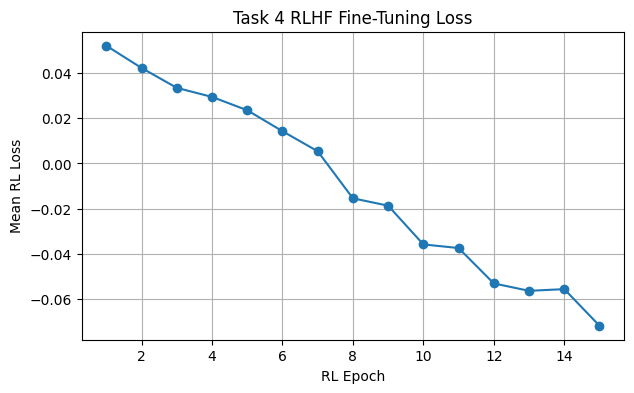

Saved plot: /content/outputs_task4_rlhf/plots/task4_rl_loss_curve.png


In [112]:
import os
import matplotlib.pyplot as plt

TASK4_PLOTS_DIR = os.path.join(TASK4_DIR, "plots")
os.makedirs(TASK4_PLOTS_DIR, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(rl_history_df["epoch"], rl_history_df["mean_loss"], marker="o")
plt.xlabel("RL Epoch")
plt.ylabel("Mean RL Loss")
plt.title("Task 4 RLHF Fine-Tuning Loss")
plt.grid(True)

rl_plot_path = os.path.join(TASK4_PLOTS_DIR, "task4_rl_loss_curve.png")
plt.savefig(rl_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot:", rl_plot_path)

In [113]:
import os
import shutil

TASK4_DIR = "/content/outputs_task4_rlhf"

folders_to_clean = [
    os.path.join(TASK4_DIR, "after_rl_midis"),
    os.path.join(TASK4_DIR, "after_rl_audio")
]

files_to_delete = [
    os.path.join(TASK4_DIR, "after_rl_samples.csv"),
    "/content/task4_after_rl_audio.zip",
    "/content/task4_after_rl_audio_CLEAN.zip"
]

for folder in folders_to_clean:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print("Deleted folder:", folder)
    os.makedirs(folder, exist_ok=True)
    print("Recreated empty folder:", folder)

for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print("Deleted file:", file_path)

print("After-RL folders are clean now.")

Deleted folder: /content/outputs_task4_rlhf/after_rl_midis
Recreated empty folder: /content/outputs_task4_rlhf/after_rl_midis
Deleted folder: /content/outputs_task4_rlhf/after_rl_audio
Recreated empty folder: /content/outputs_task4_rlhf/after_rl_audio
Deleted file: /content/outputs_task4_rlhf/after_rl_samples.csv
Deleted file: /content/task4_after_rl_audio_CLEAN.zip
After-RL folders are clean now.


In [115]:
import os
import json
import random
import shutil
import pandas as pd
import torch

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_AFTER_DIR = os.path.join(TASK4_DIR, "after_rl_midis")

# Clean folder every time before generation
if os.path.exists(TASK4_AFTER_DIR):
    shutil.rmtree(TASK4_AFTER_DIR)
os.makedirs(TASK4_AFTER_DIR, exist_ok=True)

after_samples = []

num_after_samples = 10
genre_ids = list(available_genres)

policy_model.eval()

for i in range(1, num_after_samples + 1):
    genre_id = random.choice(genre_ids)
    genre_name = id_to_genre.get(genre_id, f"genre_{genre_id}")

    prompt = build_prompt_for_genre(
        train_records,
        genre_id,
        prompt_len=cfg.prompt_len
    )

    with torch.no_grad():
        token_seq = generate_sequence(
            policy_model,
            genre_id=genre_id,
            prompt=prompt,
            max_new_tokens=160,
            min_new_tokens=64,
            temperature=cfg.temperature,
            top_k=cfg.top_k,
            top_p=cfg.top_p,
            repetition_penalty=cfg.repetition_penalty,
            no_repeat_ngram_size=cfg.no_repeat_ngram_size,
        )

    pr = event_tokens_to_pianoroll(
        token_seq,
        id_to_token,
        pitch_dim=PITCH_DIM
    )

    # Clean filename: sample number only
    midi_path = os.path.join(
        TASK4_AFTER_DIR,
        f"after_rl_sample_{i:02d}.mid"
    )

    pianoroll_to_midi(
        pr,
        midi_path,
        fs=FS,
        min_pitch=MIN_PITCH,
        threshold=0.5,
        max_polyphony=6
    )

    after_samples.append({
        "sample_id": i,
        "stage": "after_rl",
        "genre_id": int(genre_id),
        "genre_name": genre_name,
        "midi_path": midi_path,
        "token_sequence": json.dumps([int(x) for x in token_seq])
    })

after_df = pd.DataFrame(after_samples)

after_csv = os.path.join(TASK4_DIR, "after_rl_samples.csv")
after_df.to_csv(after_csv, index=False)

display(after_df[["sample_id", "genre_name", "midi_path"]])
print("Saved after-RL sample list:", after_csv)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


,sample_id,genre_name,midi_path
0,1,rock,/content/outputs_task4_rlhf/after_rl_midis/aft...
1,2,classical,/content/outputs_task4_rlhf/after_rl_midis/aft...
2,3,pop,/content/outputs_task4_rlhf/after_rl_midis/aft...
3,4,pop,/content/outputs_task4_rlhf/after_rl_midis/aft...
4,5,pop,/content/outputs_task4_rlhf/after_rl_midis/aft...
5,6,classical,/content/outputs_task4_rlhf/after_rl_midis/aft...
6,7,rock,/content/outputs_task4_rlhf/after_rl_midis/aft...
7,8,classical,/content/outputs_task4_rlhf/after_rl_midis/aft...
8,9,rock,/content/outputs_task4_rlhf/after_rl_midis/aft...
9,10,classical,/content/outputs_task4_rlhf/after_rl_midis/aft...


Saved after-RL sample list: /content/outputs_task4_rlhf/after_rl_samples.csv


In [116]:
import glob

after_midis = sorted(glob.glob("/content/outputs_task4_rlhf/after_rl_midis/*.mid"))

print("After-RL MIDI count:", len(after_midis))

for p in after_midis:
    print(p)

After-RL MIDI count: 10
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_01.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_02.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_03.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_04.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_05.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_06.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_07.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_08.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_09.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_10.mid


In [117]:
import os
import glob
import shutil
import numpy as np
import pretty_midi
from scipy.io.wavfile import write

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_AFTER_DIR = os.path.join(TASK4_DIR, "after_rl_midis")
AFTER_AUDIO_DIR = os.path.join(TASK4_DIR, "after_rl_audio")

# Clean audio folder before conversion
if os.path.exists(AFTER_AUDIO_DIR):
    shutil.rmtree(AFTER_AUDIO_DIR)
os.makedirs(AFTER_AUDIO_DIR, exist_ok=True)

after_midis = sorted(glob.glob(os.path.join(TASK4_AFTER_DIR, "*.mid")))

print("After-RL MIDI files found:", len(after_midis))

for i, midi_path in enumerate(after_midis, start=1):
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        audio = midi_data.synthesize(fs=22050)

        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))

        audio_int16 = np.int16(audio * 32767)

        wav_path = os.path.join(
            AFTER_AUDIO_DIR,
            f"after_rl_sample_{i:02d}.wav"
        )

        write(wav_path, 22050, audio_int16)

        print("Saved:", wav_path)

    except Exception as e:
        print("Error converting:", midi_path)
        print(e)

After-RL MIDI files found: 10
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_01.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_02.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_03.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_04.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_05.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_06.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_07.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_08.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_09.wav
Saved: /content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_10.wav


In [118]:
after_wavs = sorted(glob.glob("/content/outputs_task4_rlhf/after_rl_audio/*.wav"))

print("After-RL WAV count:", len(after_wavs))

for p in after_wavs:
    print(p)

After-RL WAV count: 10
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_01.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_02.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_03.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_04.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_05.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_06.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_07.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_08.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_09.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_10.wav


In [119]:
import os

zip_path = "/content/task4_after_rl_audio_CLEAN.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

!zip -r /content/task4_after_rl_audio_CLEAN.zip /content/outputs_task4_rlhf/after_rl_audio > /dev/null

print("Created:", zip_path)

Created: /content/task4_after_rl_audio_CLEAN.zip


In [120]:
from google.colab import files

files.download("/content/task4_after_rl_audio_CLEAN.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [121]:
from google.colab import files

uploaded = files.upload()

Saving CSE425 Music Generation Listening RL Survey (Responses) - Form Responses 1.csv to CSE425 Music Generation Listening RL Survey (Responses) - Form Responses 1 (1).csv


In [103]:
import os
import re
import pandas as pd
import numpy as np

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_SURVEY_DIR = os.path.join(TASK4_DIR, "survey_results")
os.makedirs(TASK4_SURVEY_DIR, exist_ok=True)

uploaded_csv = list(uploaded.keys())[0]
after_google_csv_path = "/content/" + uploaded_csv

form_df = pd.read_csv(after_google_csv_path)

print("Loaded after-RL Google Form CSV:", after_google_csv_path)
print("Number of after-RL responses:", len(form_df))
print("Columns:", len(form_df.columns))

after_samples_path = os.path.join(TASK4_DIR, "after_rl_samples.csv")

if os.path.exists(after_samples_path):
    after_samples_df = pd.read_csv(after_samples_path)
    sample_to_genre = dict(zip(after_samples_df["sample_id"], after_samples_df["genre_name"]))
else:
    sample_to_genre = {i: f"sample_{i}" for i in range(1, 11)}
    print("Warning: after_rl_samples.csv not found. Using generic sample names.")

rating_map = {
    "coherence": ["coherence"],
    "rhythm": ["rhythm"],
    "creativity": ["creativity"],
    "genre_fit": ["genre fit", "genre_fit", "genrefit"],
    "overall": ["overall quality", "overall"]
}

def clean_rating_value(value):
    if pd.isna(value):
        return np.nan

    value_str = str(value).strip()
    match = re.search(r"[1-5]", value_str)

    if match:
        return int(match.group())

    return np.nan

rows = []

for response_index, response in form_df.iterrows():
    participant_id = f"P{response_index + 1:02d}"

    for sample_id in range(1, 11):
        output_row = {
            "participant_id": participant_id,
            "sample_id": sample_id,
            "genre_name": sample_to_genre.get(sample_id, f"sample_{sample_id}"),
            "coherence": np.nan,
            "rhythm": np.nan,
            "creativity": np.nan,
            "genre_fit": np.nan,
            "overall": np.nan,
            "comments": ""
        }

        for clean_name, possible_names in rating_map.items():
            matched_col = None

            for col in form_df.columns:
                col_lower = col.lower()

                sample_match = (
                    f"sample {sample_id}" in col_lower or
                    f"sample_{sample_id}" in col_lower or
                    f"sample{sample_id}" in col_lower
                )

                metric_match = any(name in col_lower for name in possible_names)

                if sample_match and metric_match:
                    matched_col = col
                    break

            if matched_col is not None:
                output_row[clean_name] = clean_rating_value(response[matched_col])

        rows.append(output_row)

after_survey_clean = pd.DataFrame(rows)

rating_cols = ["coherence", "rhythm", "creativity", "genre_fit", "overall"]

after_survey_clean = after_survey_clean.dropna(subset=rating_cols, how="all")

after_survey_path = os.path.join(TASK4_SURVEY_DIR, "after_rl_human_survey.csv")
after_survey_clean.to_csv(after_survey_path, index=False)

display(after_survey_clean.head(20))

print("Rows saved:", len(after_survey_clean))
print("Expected rows = number of responses × 10 samples")
print("Saved after-RL survey:", after_survey_path)

Loaded after-RL Google Form CSV: /content/CSE425 Music Generation Listening RL Survey (Responses) - Form Responses 1.csv
Number of after-RL responses: 11
Columns: 51


,participant_id,sample_id,genre_name,coherence,rhythm,creativity,genre_fit,overall,comments
0,P01,1,classical,5,5,4,5,5,
1,P01,2,classical,5,5,5,5,5,
2,P01,3,jazz,4,4,4,5,4,
3,P01,4,jazz,5,5,4,5,5,
4,P01,5,classical,5,5,4,5,5,
5,P01,6,jazz,4,4,4,4,4,
6,P01,7,rock,3,4,4,4,3,
7,P01,8,jazz,3,3,2,2,3,
8,P01,9,rock,3,3,2,2,2,
9,P01,10,pop,3,3,3,3,3,


Rows saved: 110
Expected rows = number of responses × 10 samples
Saved after-RL survey: /content/outputs_task4_rlhf/survey_results/after_rl_human_survey.csv


In [104]:
import os
import pandas as pd

after_survey_path = "/content/outputs_task4_rlhf/survey_results/after_rl_human_survey.csv"

print("Exists:", os.path.exists(after_survey_path))

after_survey_df = pd.read_csv(after_survey_path)
display(after_survey_df.head())
print("Rows:", len(after_survey_df))

Exists: True


,participant_id,sample_id,genre_name,coherence,rhythm,creativity,genre_fit,overall,comments
0,P01,1,classical,5,5,4,5,5,NaN
1,P01,2,classical,5,5,5,5,5,NaN
2,P01,3,jazz,4,4,4,5,4,NaN
3,P01,4,jazz,5,5,4,5,5,NaN
4,P01,5,classical,5,5,4,5,5,NaN


Rows: 110


In [105]:
import os
import pandas as pd
import numpy as np

TASK4_DIR = "/content/outputs_task4_rlhf"
TASK4_SURVEY_DIR = os.path.join(TASK4_DIR, "survey_results")

before_survey_path = os.path.join(TASK4_SURVEY_DIR, "human_survey.csv")
after_survey_path = os.path.join(TASK4_SURVEY_DIR, "after_rl_human_survey.csv")

before_df = pd.read_csv(before_survey_path)
after_df = pd.read_csv(after_survey_path)

rating_cols = ["coherence", "rhythm", "creativity", "genre_fit", "overall"]

for col in rating_cols:
    before_df[col] = pd.to_numeric(before_df[col], errors="coerce")
    after_df[col] = pd.to_numeric(after_df[col], errors="coerce")

before_df["human_score"] = before_df[rating_cols].mean(axis=1)
after_df["human_score"] = after_df[rating_cols].mean(axis=1)

comparison_df = pd.DataFrame([
    {
        "Model": "Before RL - Task 3 Transformer",
        "Participants": before_df["participant_id"].nunique(),
        "Mean Human Score": before_df["human_score"].mean(),
        "Mean Coherence": before_df["coherence"].mean(),
        "Mean Rhythm": before_df["rhythm"].mean(),
        "Mean Creativity": before_df["creativity"].mean(),
        "Mean Genre Fit": before_df["genre_fit"].mean(),
        "Mean Overall": before_df["overall"].mean(),
    },
    {
        "Model": "After RLHF Fine-Tuning",
        "Participants": after_df["participant_id"].nunique(),
        "Mean Human Score": after_df["human_score"].mean(),
        "Mean Coherence": after_df["coherence"].mean(),
        "Mean Rhythm": after_df["rhythm"].mean(),
        "Mean Creativity": after_df["creativity"].mean(),
        "Mean Genre Fit": after_df["genre_fit"].mean(),
        "Mean Overall": after_df["overall"].mean(),
    }
])

comparison_df["Improvement vs Before"] = comparison_df["Mean Human Score"] - comparison_df.loc[0, "Mean Human Score"]

comparison_path = os.path.join(
    TASK4_DIR,
    "task4_before_vs_after_human_comparison.csv"
)

comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)
print("Saved comparison:", comparison_path)

,Model,Participants,Mean Human Score,Mean Coherence,Mean Rhythm,Mean Creativity,Mean Genre Fit,Mean Overall,Improvement vs Before
0,Before RL - Task 3 Transformer,12,3.215000,3.341667,3.150000,2.916667,3.441667,3.225000,0.000000
1,After RLHF Fine-Tuning,11,3.229091,3.263636,3.245455,3.118182,3.300000,3.218182,0.014091


Saved comparison: /content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv


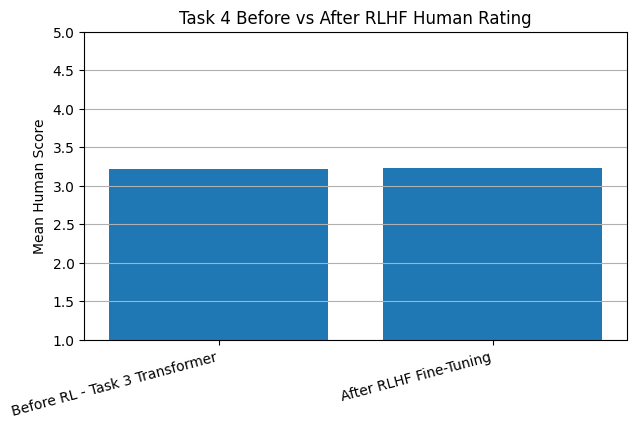

Saved plot: /content/outputs_task4_rlhf/plots/task4_before_after_human_score.png


In [106]:
import os
import matplotlib.pyplot as plt

TASK4_PLOTS_DIR = os.path.join(TASK4_DIR, "plots")
os.makedirs(TASK4_PLOTS_DIR, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.bar(
    comparison_df["Model"],
    comparison_df["Mean Human Score"]
)
plt.ylabel("Mean Human Score")
plt.title("Task 4 Before vs After RLHF Human Rating")
plt.ylim(1, 5)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")

plot_path = os.path.join(
    TASK4_PLOTS_DIR,
    "task4_before_after_human_score.png"
)

plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [107]:
import glob

task4_files = sorted(glob.glob("/content/outputs_task4_rlhf/**/*", recursive=True))

for path in task4_files:
    print(path)

/content/outputs_task4_rlhf/after_rl_audio
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_01.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_02.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_03.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_04.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_05.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_06.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_07.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_08.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_09.wav
/content/outputs_task4_rlhf/after_rl_audio/after_rl_sample_10.wav
/content/outputs_task4_rlhf/after_rl_midis
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_01.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_02.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_sample_03.mid
/content/outputs_task4_rlhf/after_rl_midis/after_rl_samp

In [122]:
import os
import glob

required_files = [
    "/content/outputs_task4_rlhf/rl_training_data.csv",
    "/content/outputs_task4_rlhf/task4_rl_training_history.csv",
    "/content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt",
    "/content/outputs_task4_rlhf/plots/task4_rl_loss_curve.png",
    "/content/outputs_task4_rlhf/after_rl_samples.csv",
    "/content/outputs_task4_rlhf/survey_results/human_survey.csv",
    "/content/outputs_task4_rlhf/survey_results/after_rl_human_survey.csv",
    "/content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv",
    "/content/outputs_task4_rlhf/plots/task4_before_after_human_score.png"
]

print("TASK 4 FINAL CHECK")
print("=" * 40)

all_good = True

for path in required_files:
    exists = os.path.exists(path)
    print(("OK   " if exists else "MISS "), path)
    if not exists:
        all_good = False

after_midis = glob.glob("/content/outputs_task4_rlhf/after_rl_midis/*.mid")
after_wavs = glob.glob("/content/outputs_task4_rlhf/after_rl_audio/*.wav")

print("\nAfter-RL MIDI count:", len(after_midis))
print("After-RL WAV count:", len(after_wavs))

if len(after_midis) != 10:
    all_good = False

if len(after_wavs) != 10:
    all_good = False

required_vars = [
    "sequence_logprob",
    "rl_history",
    "rl_history_df",
    "policy_model",
    "ref_model"
]

print("\nVariable check")
print("=" * 40)

for var in required_vars:
    exists = var in globals()
    print(("OK   " if exists else "MISS "), var)
    if not exists:
        all_good = False

print("\nFinal Task 4 status:")
if all_good:
    print("TASK 4 LOOKS COMPLETE.")
else:
    print("TASK 4 STILL HAS MISSING ITEMS.")

TASK 4 FINAL CHECK
OK    /content/outputs_task4_rlhf/rl_training_data.csv
OK    /content/outputs_task4_rlhf/task4_rl_training_history.csv
OK    /content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt
OK    /content/outputs_task4_rlhf/plots/task4_rl_loss_curve.png
OK    /content/outputs_task4_rlhf/after_rl_samples.csv
OK    /content/outputs_task4_rlhf/survey_results/human_survey.csv
OK    /content/outputs_task4_rlhf/survey_results/after_rl_human_survey.csv
OK    /content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv
OK    /content/outputs_task4_rlhf/plots/task4_before_after_human_score.png

After-RL MIDI count: 10
After-RL WAV count: 10

Variable check
OK    sequence_logprob
OK    rl_history
OK    rl_history_df
OK    policy_model
OK    ref_model

Final Task 4 status:
TASK 4 LOOKS COMPLETE.


# Baseline Models for Comparison

The project guideline requires comparison against at least two baseline models. We implemented:

1. Random Note Generator: randomly activates notes in a piano-roll representation.
2. Markov Chain Music Model: learns token-to-token transition probabilities from the training sequences and generates music autoregressively.

These baselines are compared against Task 1–Task 4 using available quantitative and qualitative metrics.

In [123]:
import os
import json
import glob
import random
import numpy as np
import pandas as pd
import torch

BASELINE_DIR = "/content/outputs_baselines"
RANDOM_BASELINE_DIR = os.path.join(BASELINE_DIR, "random_generator_midis")
MARKOV_BASELINE_DIR = os.path.join(BASELINE_DIR, "markov_chain_midis")
BASELINE_PLOTS_DIR = os.path.join(BASELINE_DIR, "plots")

os.makedirs(RANDOM_BASELINE_DIR, exist_ok=True)
os.makedirs(MARKOV_BASELINE_DIR, exist_ok=True)
os.makedirs(BASELINE_PLOTS_DIR, exist_ok=True)

print("Baseline folders created:")
print(BASELINE_DIR)

Baseline folders created:
/content/outputs_baselines


In [124]:
def generate_random_pianoroll(
    seq_len=256,
    pitch_dim=88,
    note_probability=0.035,
    max_polyphony=5
):
    """
    Naive random note generator.
    Creates a binary piano-roll with random note activations.
    """
    pr = np.zeros((seq_len, pitch_dim), dtype=np.float32)

    for t in range(seq_len):
        active_count = np.random.randint(0, max_polyphony + 1)

        if active_count > 0:
            pitches = np.random.choice(
                pitch_dim,
                size=active_count,
                replace=False
            )

            for p in pitches:
                if np.random.rand() < note_probability * 10:
                    pr[t, p] = 1.0

    return pr


random_baseline_rows = []

NUM_BASELINE_SAMPLES = 10

for i in range(1, NUM_BASELINE_SAMPLES + 1):
    pr = generate_random_pianoroll(
        seq_len=256,
        pitch_dim=PITCH_DIM,
        note_probability=0.035,
        max_polyphony=5
    )

    midi_path = os.path.join(
        RANDOM_BASELINE_DIR,
        f"random_baseline_{i:02d}.mid"
    )

    pianoroll_to_midi(
        pr,
        midi_path,
        fs=FS,
        min_pitch=MIN_PITCH,
        threshold=0.5,
        max_polyphony=6
    )

    random_baseline_rows.append({
        "sample_id": i,
        "model": "Random Generator",
        "midi_path": midi_path
    })

random_baseline_df = pd.DataFrame(random_baseline_rows)

random_csv = os.path.join(BASELINE_DIR, "random_baseline_samples.csv")
random_baseline_df.to_csv(random_csv, index=False)

display(random_baseline_df)
print("Saved random baseline samples:", random_csv)

,sample_id,model,midi_path
0,1,Random Generator,/content/outputs_baselines/random_generator_mi...
1,2,Random Generator,/content/outputs_baselines/random_generator_mi...
2,3,Random Generator,/content/outputs_baselines/random_generator_mi...
3,4,Random Generator,/content/outputs_baselines/random_generator_mi...
4,5,Random Generator,/content/outputs_baselines/random_generator_mi...
5,6,Random Generator,/content/outputs_baselines/random_generator_mi...
6,7,Random Generator,/content/outputs_baselines/random_generator_mi...
7,8,Random Generator,/content/outputs_baselines/random_generator_mi...
8,9,Random Generator,/content/outputs_baselines/random_generator_mi...
9,10,Random Generator,/content/outputs_baselines/random_generator_mi...


Saved random baseline samples: /content/outputs_baselines/random_baseline_samples.csv


In [125]:
from collections import defaultdict, Counter

def extract_token_sequence_from_record(record):
    """
    Safely extracts token sequence from a train_records item.
    Works for common keys used in the notebook.
    """
    if isinstance(record, dict):
        for key in ["token_ids", "tokens", "input_ids", "sequence"]:
            if key in record:
                return list(record[key])

    if isinstance(record, (list, tuple)):
        return list(record)

    raise ValueError("Could not extract token sequence from record.")


def build_markov_chain(records, max_records=None):
    transition_counts = defaultdict(Counter)

    used = records if max_records is None else records[:max_records]

    for rec in used:
        try:
            seq = extract_token_sequence_from_record(rec)
        except Exception:
            continue

        for a, b in zip(seq[:-1], seq[1:]):
            transition_counts[int(a)][int(b)] += 1

    transition_probs = {}

    for token, counter in transition_counts.items():
        next_tokens = np.array(list(counter.keys()), dtype=np.int64)
        counts = np.array(list(counter.values()), dtype=np.float64)
        probs = counts / counts.sum()

        transition_probs[token] = {
            "next_tokens": next_tokens,
            "probs": probs
        }

    return transition_probs


def sample_markov_sequence(
    transition_probs,
    start_token,
    max_len=256,
    fallback_tokens=None
):
    seq = [int(start_token)]
    current = int(start_token)

    if fallback_tokens is None:
        fallback_tokens = list(transition_probs.keys())

    for _ in range(max_len - 1):
        if current in transition_probs:
            next_tokens = transition_probs[current]["next_tokens"]
            probs = transition_probs[current]["probs"]
            next_token = int(np.random.choice(next_tokens, p=probs))
        else:
            next_token = int(random.choice(fallback_tokens))

        seq.append(next_token)
        current = next_token

    return seq


markov_chain = build_markov_chain(train_records)

print("Markov states learned:", len(markov_chain))

Markov states learned: 166


In [126]:
markov_rows = []

markov_start_tokens = list(markov_chain.keys())

for i in range(1, NUM_BASELINE_SAMPLES + 1):
    start_token = random.choice(markov_start_tokens)

    token_seq = sample_markov_sequence(
        markov_chain,
        start_token=start_token,
        max_len=256,
        fallback_tokens=markov_start_tokens
    )

    pr = event_tokens_to_pianoroll(
        token_seq,
        id_to_token,
        pitch_dim=PITCH_DIM
    )

    midi_path = os.path.join(
        MARKOV_BASELINE_DIR,
        f"markov_baseline_{i:02d}.mid"
    )

    pianoroll_to_midi(
        pr,
        midi_path,
        fs=FS,
        min_pitch=MIN_PITCH,
        threshold=0.5,
        max_polyphony=6
    )

    markov_rows.append({
        "sample_id": i,
        "model": "Markov Chain",
        "midi_path": midi_path,
        "num_tokens": len(token_seq),
        "token_sequence": json.dumps([int(x) for x in token_seq])
    })

markov_baseline_df = pd.DataFrame(markov_rows)

markov_csv = os.path.join(BASELINE_DIR, "markov_baseline_samples.csv")
markov_baseline_df.to_csv(markov_csv, index=False)

display(markov_baseline_df[["sample_id", "model", "num_tokens", "midi_path"]])
print("Saved Markov baseline samples:", markov_csv)

,sample_id,model,num_tokens,midi_path
0,1,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
1,2,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
2,3,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
3,4,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
4,5,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
5,6,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
6,7,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
7,8,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
8,9,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...
9,10,Markov Chain,256,/content/outputs_baselines/markov_chain_midis/...


Saved Markov baseline samples: /content/outputs_baselines/markov_baseline_samples.csv


In [127]:
def pianoroll_rhythm_diversity(pr):
    """
    Simple rhythm diversity:
    number of unique note counts per time step / total active time steps.
    """
    note_counts = pr.sum(axis=1)
    active_counts = note_counts[note_counts > 0]

    if len(active_counts) == 0:
        return 0.0

    return len(np.unique(active_counts)) / len(active_counts)


def pianoroll_repetition_ratio(pr, window=8):
    """
    Simple repetition ratio:
    repeated piano-roll patterns / total patterns.
    """
    if len(pr) < window:
        return 0.0

    patterns = []

    for i in range(0, len(pr) - window + 1, window):
        patterns.append(pr[i:i+window].astype(int).tobytes())

    if len(patterns) == 0:
        return 0.0

    repeated = len(patterns) - len(set(patterns))
    return repeated / len(patterns)


def midi_to_simple_pianoroll(midi_path, fs=FS, min_pitch=MIN_PITCH, pitch_dim=PITCH_DIM):
    """
    Converts MIDI back to a simple binary piano-roll for evaluation.
    """
    import pretty_midi

    midi = pretty_midi.PrettyMIDI(midi_path)
    roll = midi.get_piano_roll(fs=fs)

    start = min_pitch
    end = min_pitch + pitch_dim

    roll = roll[start:end, :].T

    if roll.shape[1] < pitch_dim:
        pad_width = pitch_dim - roll.shape[1]
        roll = np.pad(roll, ((0, 0), (0, pad_width)))

    roll = roll[:, :pitch_dim]
    binary_roll = (roll > 0).astype(np.float32)

    return binary_roll


def evaluate_midi_folder(folder, model_name):
    rows = []

    midi_files = sorted(glob.glob(os.path.join(folder, "*.mid")))

    for path in midi_files:
        try:
            pr = midi_to_simple_pianoroll(path)

            rows.append({
                "model": model_name,
                "file": os.path.basename(path),
                "rhythm_diversity": pianoroll_rhythm_diversity(pr),
                "repetition_ratio": pianoroll_repetition_ratio(pr),
                "active_note_density": float(pr.mean())
            })

        except Exception as e:
            rows.append({
                "model": model_name,
                "file": os.path.basename(path),
                "rhythm_diversity": np.nan,
                "repetition_ratio": np.nan,
                "active_note_density": np.nan,
                "error": str(e)
            })

    return pd.DataFrame(rows)


random_metrics_df = evaluate_midi_folder(
    RANDOM_BASELINE_DIR,
    "Random Generator"
)

markov_metrics_df = evaluate_midi_folder(
    MARKOV_BASELINE_DIR,
    "Markov Chain"
)

baseline_metrics_df = pd.concat(
    [random_metrics_df, markov_metrics_df],
    ignore_index=True
)

baseline_metrics_path = os.path.join(BASELINE_DIR, "baseline_metrics.csv")
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

display(baseline_metrics_df)
print("Saved baseline metrics:", baseline_metrics_path)

,model,file,rhythm_diversity,repetition_ratio,active_note_density
0,Random Generator,random_baseline_01.mid,0.027972,0.0,0.010254
1,Random Generator,random_baseline_02.mid,0.026846,0.0,0.010782
2,Random Generator,random_baseline_03.mid,0.026316,0.0,0.011097
3,Random Generator,random_baseline_04.mid,0.021277,0.0,0.009632
4,Random Generator,random_baseline_05.mid,0.021898,0.0,0.008824
5,Random Generator,random_baseline_06.mid,0.028169,0.0,0.010740
6,Random Generator,random_baseline_07.mid,0.027778,0.0,0.009766
7,Random Generator,random_baseline_08.mid,0.026667,0.0,0.011053
8,Random Generator,random_baseline_09.mid,0.031008,0.0,0.009028
9,Random Generator,random_baseline_10.mid,0.028169,0.0,0.010165


Saved baseline metrics: /content/outputs_baselines/baseline_metrics.csv


In [128]:
baseline_summary_df = baseline_metrics_df.groupby("model").agg({
    "rhythm_diversity": "mean",
    "repetition_ratio": "mean",
    "active_note_density": "mean"
}).reset_index()

display(baseline_summary_df)

baseline_summary_path = os.path.join(BASELINE_DIR, "baseline_summary_metrics.csv")
baseline_summary_df.to_csv(baseline_summary_path, index=False)

print("Saved baseline summary:", baseline_summary_path)

,model,rhythm_diversity,repetition_ratio,active_note_density
0,Markov Chain,0.611771,0.0,0.059677
1,Random Generator,0.026610,0.0,0.010134


Saved baseline summary: /content/outputs_baselines/baseline_summary_metrics.csv


In [132]:
performance_rows = [
    {
        "Model": "Random Generator",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": "Low",
        "Human Score": "Not surveyed",
        "Genre Control": "None"
    },
    {
        "Model": "Markov Chain",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": "Medium",
        "Human Score": "Not surveyed",
        "Genre Control": "Weak"
    },
    {
        "Model": "Task 1: Autoencoder",
        "Loss": "0.4934",
        "Perplexity": "-",
        "Rhythm Diversity": "Medium",
        "Human Score": "-",
        "Genre Control": "Single Genre"
    },
    {
        "Model": "Task 2: VAE Multi-Genre",
        "Loss": "0.2320",
        "Perplexity": "-",
        "Rhythm Diversity": "High",
        "Human Score": "-",
        "Genre Control": "Moderate"
    },
    {
        "Model": "Task 3: Transformer",
        "Loss": "-",
        "Perplexity": "8.4752",
        "Rhythm Diversity": "High",
        "Human Score": "-",
        "Genre Control": "Strong"
    },
    {
        "Model": "Task 4: RLHF-Tuned Model",
        "Loss": "-",
        "Perplexity": "-",
        "Rhythm Diversity": "High",
        "Human Score": "3.2291",
        "Genre Control": "Strongest"
    }
]

performance_comparison_df = pd.DataFrame(performance_rows)

performance_table_path = os.path.join(
    BASELINE_DIR,
    "performance_comparison_task1_to_task4.csv"
)

performance_comparison_df.to_csv(performance_table_path, index=False)

display(performance_comparison_df)
print("Saved performance comparison table:", performance_table_path)

,Model,Loss,Perplexity,Rhythm Diversity,Human Score,Genre Control
0,Random Generator,-,-,Low,Not surveyed,None
1,Markov Chain,-,-,Medium,Not surveyed,Weak
2,Task 1: Autoencoder,0.4934,-,Medium,-,Single Genre
3,Task 2: VAE Multi-Genre,0.2320,-,High,-,Moderate
4,Task 3: Transformer,-,8.4752,High,-,Strong
5,Task 4: RLHF-Tuned Model,-,-,High,3.2291,Strongest


Saved performance comparison table: /content/outputs_baselines/performance_comparison_task1_to_task4.csv


In [138]:
import glob
import os

print("Searching for Task 3 MIDI files...")
task3_candidates = glob.glob("/content/outputs_task3_transformer/**/*.mid", recursive=True)

print("Found Task 3 MIDI files:", len(task3_candidates))

for path in task3_candidates[:20]:
    print(path)

Searching for Task 3 MIDI files...
Found Task 3 MIDI files: 10
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_05_classical.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_06_jazz.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_01_classical.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_04_rock.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_03_pop.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_07_pop.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_08_rock.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_10_jazz.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_09_classical.mid
/content/outputs_task3_transformer/generated_midis_task3/task3_sample_02_jazz.mid


In [139]:
import glob
import os

print("Searching for Task 3 CSV files...")
task3_csvs = glob.glob("/content/outputs_task3_transformer/**/*.csv", recursive=True)

print("Found Task 3 CSV files:", len(task3_csvs))

for path in task3_csvs:
    print(path)

Searching for Task 3 CSV files...
Found Task 3 CSV files: 1
/content/outputs_task3_transformer/task3_training_history.csv


In [141]:
import os
import glob
import pandas as pd

TASK3_DIR = "/content/outputs_task3_transformer"
TASK3_MIDI_DIR = os.path.join(TASK3_DIR, "generated_midis_task3")

task3_midi_files = sorted(glob.glob(os.path.join(TASK3_MIDI_DIR, "*.mid")))

task3_rows = []

for i, path in enumerate(task3_midi_files, start=1):
    filename = os.path.basename(path)

    # Try to extract genre from filename like:
    # task3_sample_01_classical.mid
    parts = filename.replace(".mid", "").split("_")
    genre_name = parts[-1] if len(parts) > 0 else "unknown"

    task3_rows.append({
        "sample_id": i,
        "filename": filename,
        "genre_name": genre_name,
        "midi_path": path
    })

task3_generated_samples_df = pd.DataFrame(task3_rows)

task3_generated_csv = os.path.join(
    TASK3_DIR,
    "task3_generated_samples.csv"
)

task3_generated_samples_df.to_csv(task3_generated_csv, index=False)

display(task3_generated_samples_df)

print("Saved Task 3 generated samples CSV:", task3_generated_csv)
print("Task 3 generated MIDI count:", len(task3_generated_samples_df))

,sample_id,filename,genre_name,midi_path
0,1,task3_sample_01_classical.mid,classical,/content/outputs_task3_transformer/generated_m...
1,2,task3_sample_02_jazz.mid,jazz,/content/outputs_task3_transformer/generated_m...
2,3,task3_sample_03_pop.mid,pop,/content/outputs_task3_transformer/generated_m...
3,4,task3_sample_04_rock.mid,rock,/content/outputs_task3_transformer/generated_m...
4,5,task3_sample_05_classical.mid,classical,/content/outputs_task3_transformer/generated_m...
5,6,task3_sample_06_jazz.mid,jazz,/content/outputs_task3_transformer/generated_m...
6,7,task3_sample_07_pop.mid,pop,/content/outputs_task3_transformer/generated_m...
7,8,task3_sample_08_rock.mid,rock,/content/outputs_task3_transformer/generated_m...
8,9,task3_sample_09_classical.mid,classical,/content/outputs_task3_transformer/generated_m...
9,10,task3_sample_10_jazz.mid,jazz,/content/outputs_task3_transformer/generated_m...


Saved Task 3 generated samples CSV: /content/outputs_task3_transformer/task3_generated_samples.csv
Task 3 generated MIDI count: 10


In [142]:
import os
import glob

required_project_paths = [
    "/content/outputs_task1_fixed/loss_curve_task1.png",
    "/content/outputs_task1_fixed/task1_metrics.csv",
    "/content/outputs_task2_vae/task2_metrics.csv",
    "/content/outputs_task2_vae/task1_vs_task2_comparison.csv",
    "/content/outputs_task3_transformer/best_task3_transformer.pt",
    "/content/outputs_task3_transformer/task3_training_history.csv",
    "/content/outputs_task3_transformer/task3_generated_samples.csv",
    "/content/outputs_task4_rlhf/task4_rl_training_history.csv",
    "/content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt",
    "/content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv",
    "/content/outputs_baselines/performance_comparison_task1_to_task4.csv",
]

print("FULL PROJECT FINAL CHECK")
print("=" * 45)

all_good = True

for path in required_project_paths:
    exists = os.path.exists(path)
    print(("OK   " if exists else "MISS "), path)
    if not exists:
        all_good = False

task1_gen = glob.glob("/content/outputs_task1_fixed/generated_midis_task1_sampled/*.mid")
task2_gen = glob.glob("/content/outputs_task2_vae/generated_midis_task2/*.mid")
task3_gen = glob.glob("/content/outputs_task3_transformer/generated_midis_task3/*.mid")
task4_gen = glob.glob("/content/outputs_task4_rlhf/after_rl_midis/*.mid")
random_gen = glob.glob("/content/outputs_baselines/random_generator_midis/*.mid")
markov_gen = glob.glob("/content/outputs_baselines/markov_chain_midis/*.mid")

print("\nGenerated MIDI counts")
print("=" * 45)
print("Task 1 generated MIDI:", len(task1_gen))
print("Task 2 generated MIDI:", len(task2_gen))
print("Task 3 generated MIDI:", len(task3_gen))
print("Task 4 after-RL MIDI:", len(task4_gen))
print("Random baseline MIDI:", len(random_gen))
print("Markov baseline MIDI:", len(markov_gen))

if len(task1_gen) < 5:
    all_good = False
if len(task2_gen) < 8:
    all_good = False
if len(task3_gen) < 10:
    all_good = False
if len(task4_gen) < 10:
    all_good = False
if len(random_gen) < 5:
    all_good = False
if len(markov_gen) < 5:
    all_good = False

print("\nFinal project status:")
if all_good:
    print("PROJECT OUTPUTS LOOK COMPLETE.")
else:
    print("PROJECT STILL HAS MISSING ITEMS.")

FULL PROJECT FINAL CHECK
OK    /content/outputs_task1_fixed/loss_curve_task1.png
OK    /content/outputs_task1_fixed/task1_metrics.csv
OK    /content/outputs_task2_vae/task2_metrics.csv
OK    /content/outputs_task2_vae/task1_vs_task2_comparison.csv
OK    /content/outputs_task3_transformer/best_task3_transformer.pt
OK    /content/outputs_task3_transformer/task3_training_history.csv
OK    /content/outputs_task3_transformer/task3_generated_samples.csv
OK    /content/outputs_task4_rlhf/task4_rl_training_history.csv
OK    /content/outputs_task4_rlhf/models/task4_rlhf_tuned_transformer.pt
OK    /content/outputs_task4_rlhf/task4_before_vs_after_human_comparison.csv
OK    /content/outputs_baselines/performance_comparison_task1_to_task4.csv

Generated MIDI counts
Task 1 generated MIDI: 5
Task 2 generated MIDI: 8
Task 3 generated MIDI: 10
Task 4 after-RL MIDI: 10
Random baseline MIDI: 10
Markov baseline MIDI: 10

Final project status:
PROJECT OUTPUTS LOOK COMPLETE.


In [133]:
!zip -r /content/final_project_outputs.zip \
    /content/outputs_task1_fixed \
    /content/outputs_task2_vae \
    /content/outputs_task3_transformer \
    /content/outputs_task4_rlhf \
    /content/outputs_baselines > /dev/null

from google.colab import files
files.download("/content/final_project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>